<a href="https://colab.research.google.com/github/Ashish0011-ashu/soil-moisture-pinn/blob/main/cdsAPI_(2)_(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
!pip install cdsapi

In [3]:
import os

content = """
url:https://cds.climate.copernicus.eu/api
key:bd1b2cc2-9653-40db-91a4-df23df144631
"""
with open("/root/.cdsapirc","w") as f:
   f.write(content)

print("configuration file created")

configuration file created


In [4]:
!cat /root/.cdsapirc


url:https://cds.climate.copernicus.eu/api
key:bd1b2cc2-9653-40db-91a4-df23df144631


In [5]:
!pip install -U cdsapi

In [6]:
import cdsapi

client = cdsapi.Client()

print("✅ Connected to Copernicus CDS!")

✅ Connected to Copernicus CDS!


we just test weather my code i working poperly or not then we apply loop for downloding direct all monthly data samples from 2020 to 2026

In [7]:
import cdsapi

client = cdsapi.Client()

dataset = "reanalysis-era5-land"

request = {
     "variable":[
         "2m_temperature",
         "total_precipitation"
     ],
     "year":"2020",
     "month":"01",
     "day":[
         "01", "02", "03",
         "04", "05", "06",
         "07", "08", "09",
         "10", "11", "12",
         "13", "14", "15",
         "16", "17", "18",
         "19", "20", "21",
         "22", "23", "24",
         "25", "26", "27",
         "28", "29", "30",
         "31"
     ],
     "time":[
         "00:00"
     ],
     "data_format":"netcdf",
     "download_format":"unarchived",
     "area":[
         27.5, #North
         83.0, #West
         24.0, #South
         88.5 #East
     ]
}

client.retrieve(
    dataset,
    request,
    "bihar_jan2020.nc"
)
print("✅ Download Complete!")

2026-07-03 10:37:58,471 INFO Request ID is fb4e035d-1a65-40c0-8838-1f9e957c5bfe
INFO:ecmwf.datastores.legacy_client:Request ID is fb4e035d-1a65-40c0-8838-1f9e957c5bfe
2026-07-03 10:37:58,606 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-03 10:38:21,754 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


2c44532cc35651a6d2587de0ed75d683.nc:   0%|          | 0.00/245k [00:00<?, ?B/s]

✅ Download Complete!


In [8]:
import cdsapi

client = cdsapi.Client()

dataset = "reanalysis-era5-land"

for year in range(2020, 2025):

    request = {
        "variable": [
            "2m_temperature",
            "total_precipitation"
        ],

        "year": str(year),

        "month": [
            "01", "02", "03", "04", "05", "06",
            "07", "08", "09", "10", "11", "12"
        ],

        "day": [
            "01","02","03","04","05","06","07","08","09","10",
            "11","12","13","14","15","16","17","18","19","20",
            "21","22","23","24","25","26","27","28","29","30","31"
        ],

        "time": ["00:00"],

        "data_format": "netcdf",
        "download_format": "unarchived",

        "area": [
            27.5,
            83.0,
            24.0,
            88.5
        ]
    }

    client.retrieve(
        dataset,
        request,
        f"bihar_{year}.nc"
    )

    print(f"✅ {year} downloaded!")

2026-07-03 10:38:24,197 INFO Request ID is f1d097b2-fb03-49c7-bf68-12a7759e4139
INFO:ecmwf.datastores.legacy_client:Request ID is f1d097b2-fb03-49c7-bf68-12a7759e4139
2026-07-03 10:38:24,322 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-03 10:38:34,467 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


a0c9d7c94c249b2cc1eb0dab67606138.nc:   0%|          | 0.00/2.55M [00:00<?, ?B/s]

✅ 2020 downloaded!


2026-07-03 10:38:36,527 INFO Request ID is 7b7ce7b0-f38d-4418-b648-169e7cb660fc
INFO:ecmwf.datastores.legacy_client:Request ID is 7b7ce7b0-f38d-4418-b648-169e7cb660fc
2026-07-03 10:38:36,652 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-03 10:38:50,626 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


be7a8abb12603fd7655883bdd44dbc18.nc:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

88317ae5249933405d34ad03de14ef62.nc:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

✅ 2023 downloaded!


2026-07-03 10:39:32,724 INFO Request ID is 3bf13cb3-af27-451c-a942-9519774cbf92
INFO:ecmwf.datastores.legacy_client:Request ID is 3bf13cb3-af27-451c-a942-9519774cbf92
2026-07-03 10:39:32,858 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-03 10:39:44,650 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-03 10:39:49,844 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


ddfa51cf98327ef95bf063dd9a4fe5b2.nc:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

✅ 2024 downloaded!


In [9]:
import os
import cdsapi

client = cdsapi.Client()

dataset = "reanalysis-era5-land"

for year in range(2020, 2025):

    filename = f"bihar_{year}.nc"

    if os.path.exists(filename):
        print(f"✅ {filename} already exists. Skipping...")
        continue

    request = {
        "variable": [
            "2m_temperature",
            "total_precipitation"
        ],
        "year": str(year),
        "month": [
            "01","02","03","04","05","06",
            "07","08","09","10","11","12"
        ],
        "day": [
            "01","02","03","04","05","06","07","08","09","10",
            "11","12","13","14","15","16","17","18","19","20",
            "21","22","23","24","25","26","27","28","29","30","31"
        ],
        "time": ["00:00"],
        "data_format": "netcdf",
        "download_format": "unarchived",
        "area": [
            27.5,
            83.0,
            24.0,
            88.5
        ]
    }

    client.retrieve(dataset, request, filename)

    print(f"✅ Downloaded {filename}")


✅ bihar_2020.nc already exists. Skipping...
✅ bihar_2021.nc already exists. Skipping...
✅ bihar_2022.nc already exists. Skipping...
✅ bihar_2023.nc already exists. Skipping...
✅ bihar_2024.nc already exists. Skipping...


Open one ERA5 file

In [10]:
import xarray as xr

ds = xr.open_dataset("bihar_2020.nc")

print(ds)

<xarray.Dataset> Size: 6MB
Dimensions:     (valid_time: 366, latitude: 36, longitude: 56)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2020-01-01 ... 2020-12-31
  * latitude    (latitude) float64 288B 27.5 27.4 27.3 27.2 ... 24.2 24.1 24.0
  * longitude   (longitude) float64 448B 83.0 83.1 83.2 83.3 ... 88.3 88.4 88.5
    number      int64 8B ...
    expver      (valid_time) <U4 6kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 3MB ...
    tp          (valid_time, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-27T16:38 GRIB to CDM+CF via cfgrib-0.9.1...


In [11]:
print("Number of time steps:", len(ds.valid_time))
print(ds.valid_time.values[:5])    # First 5 dates
print(ds.valid_time.values[-5:])   # Last 5 dates

Number of time steps: 366
['2020-01-01T00:00:00.000000000' '2020-01-02T00:00:00.000000000'
 '2020-01-03T00:00:00.000000000' '2020-01-04T00:00:00.000000000'
 '2020-01-05T00:00:00.000000000']
['2020-12-27T00:00:00.000000000' '2020-12-28T00:00:00.000000000'
 '2020-12-29T00:00:00.000000000' '2020-12-30T00:00:00.000000000'
 '2020-12-31T00:00:00.000000000']


# Verify your soil moisture CSV

In [12]:
from google.colab import files

uploaded = files.upload()

Saving bihar_rootzone_soil_moisture_2020_2024.csv to bihar_rootzone_soil_moisture_2020_2024.csv


In [13]:
import pandas as pd

sm = pd.read_csv("bihar_rootzone_soil_moisture_2020_2024.csv")

print(sm.head())
print(sm.columns)
print(sm.shape)

         time     lat     lon   rzsm_1m
0  01-01-2020  27.375  83.125  0.253092
1  01-01-2020  27.375  83.375  0.253460
2  01-01-2020  27.375  83.625  0.246107
3  01-01-2020  27.375  83.875  0.242253
4  01-01-2020  27.375  84.125  0.255178
Index(['time', 'lat', 'lon', 'rzsm_1m'], dtype='object')
(55160, 4)


Combine all ERA5 files

In [14]:
import xarray as xr

files =[
    "bihar_2020.nc",
    "bihar_2021.nc",
    "bihar_2022.nc",
    "bihar_2023.nc",
    "bihar_2024.nc"
]
era5 = xr.open_mfdataset(files, combine="by_coords")
print(era5)

<xarray.Dataset> Size: 30MB
Dimensions:     (valid_time: 1827, latitude: 36, longitude: 56)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 15kB 2020-01-01 ... 2024-12-31
  * latitude    (latitude) float64 288B 27.5 27.4 27.3 27.2 ... 24.2 24.1 24.0
  * longitude   (longitude) float64 448B 83.0 83.1 83.2 83.3 ... 88.3 88.4 88.5
    number      int64 8B 0
    expver      (valid_time) <U4 29kB dask.array<chunksize=(366,), meta=np.ndarray>
Data variables:
    t2m         (valid_time, latitude, longitude) float32 15MB dask.array<chunksize=(366, 36, 56), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 15MB dask.array<chunksize=(366, 36, 56), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 

interpolate  ERA5 to the soil Moisture Grid

In [15]:
import pandas as pd
import xarray as xr
sm = pd.read_csv("bihar_rootzone_soil_moisture_2020_2024.csv")

# Get unique grid coordinates
sm_lat = sorted(sm["lat"].unique())
sm_lon = sorted(sm["lon"].unique())

print("Latitudes:", len(sm_lat))
print("Longitudes:", len(sm_lon))

Latitudes: 14
Longitudes: 22


In [16]:
era5_interp = era5.interp(
    latitude=sm_lat,
    longitude=sm_lon,
    method="linear"
)

print(era5_interp)

<xarray.Dataset> Size: 5MB
Dimensions:     (valid_time: 1827, latitude: 14, longitude: 22)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 15kB 2020-01-01 ... 2024-12-31
  * latitude    (latitude) float64 112B 24.12 24.38 24.62 ... 26.88 27.12 27.38
  * longitude   (longitude) float64 176B 83.12 83.38 83.62 ... 87.88 88.12 88.38
    number      int64 8B 0
    expver      (valid_time) <U4 29kB dask.array<chunksize=(366,), meta=np.ndarray>
Data variables:
    t2m         (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(366, 14, 22), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(366, 14, 22), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2

In [17]:
import pandas as pd
sm = pd.read_csv("bihar_rootzone_soil_moisture_2020_2024.csv")



sm["time"] = pd.to_datetime(
    sm["time"],
    format="%d-%m-%Y"
)

print(sm["time"].head())
print("Unique dates:", sm["time"].nunique())

0   2020-01-01
1   2020-01-01
2   2020-01-01
3   2020-01-01
4   2020-01-01
Name: time, dtype: datetime64[ns]
Unique dates: 180


In [18]:
era_dates = pd.to_datetime(era5_interp.valid_time.values)

missing = set(sm["time"].unique()) - set(era_dates)

print("Missing dates:", len(missing))
print(missing)

Missing dates: 0
set()


convert ERA5 to a DataFrame

In [19]:
# Convert ERA5 Dataset to DataFrame
era_df = era5_interp.to_dataframe().reset_index()

# Keep only the required columns
era_df = era_df[
    ["valid_time", "latitude", "longitude", "t2m", "tp"]
]

# Rename columns to match the soil moisture CSV
era_df.rename(
    columns={
        "valid_time": "time",
        "latitude": "lat",
        "longitude": "lon"
    },
    inplace=True
)

print(era_df.head())
print(era_df.shape)

        time     lat     lon         t2m        tp
0 2020-01-01  24.125  83.125  286.039673  0.001889
1 2020-01-01  24.125  83.375  285.692383  0.001986
2 2020-01-01  24.125  83.625  285.393921  0.001762
3 2020-01-01  24.125  83.875  285.348389  0.001451
4 2020-01-01  24.125  84.125  285.057007  0.001115
(562716, 5)


Merge with soil Moisture

In [20]:
merged = pd.merge(
    sm,
    era_df,
    on=["time", "lat", "lon"],
    how="inner"
)

print(merged.head())
print(merged.shape)

        time     lat     lon   rzsm_1m         t2m        tp
0 2020-01-01  27.375  83.125  0.253092  283.015869  0.000002
1 2020-01-01  27.375  83.375  0.253460  281.824585  0.000002
2 2020-01-01  27.375  83.625  0.246107  281.493652  0.000002
3 2020-01-01  27.375  83.875  0.242253  280.761963  0.000002
4 2020-01-01  27.375  84.125  0.255178  281.097778  0.000002
(55160, 6)


save the merger

In [21]:
# merged.to_csv(
#     "bihar_final_dataset.csv",
#     index=False
# )

# print("Dataset Saved Successfully!")


# from google.colab import files

# files.download("bihar_final_dataset.csv")

# Feature Engineering

Previous rainfall(10-days)->soil moisture has temporal memory.

Rolling temperature->Captures accumulated rainfall.

Day of year->Seasonal variation.

month->Monsoon vs dry season.

latitude->Spatial Information.

longitude->Spatial Information

In [22]:
import pandas as pd
import numpy as np

from google.colab import files

uploaded = files.upload()
df = pd.read_csv("bihar_final_dataset (3).csv")

df["time"]=pd.to_datetime(df["time"])
print(df.head())
print(df.shape)

Saving bihar_final_dataset (3).csv to bihar_final_dataset (3).csv
        time     lat     lon   rzsm_1m         t2m        tp
0 2020-01-01  27.375  83.125  0.253092  283.015869  0.000002
1 2020-01-01  27.375  83.375  0.253460  281.824585  0.000002
2 2020-01-01  27.375  83.625  0.246107  281.493652  0.000002
3 2020-01-01  27.375  83.875  0.242253  280.761963  0.000002
4 2020-01-01  27.375  84.125  0.255178  281.097778  0.000002
(55160, 6)


create temporal features

In [23]:
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["day_of_year"] = df["time"].dt.dayofyear

cyclic encoding

In [24]:
df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

df["doy_sin"] = np.sin(2*np.pi*df["day_of_year"]/365)
df["doy_cos"] = np.cos(2*np.pi*df["day_of_year"]/365)
print(df.columns)

print(df.head())

Index(['time', 'lat', 'lon', 'rzsm_1m', 't2m', 'tp', 'year', 'month', 'day',
       'day_of_year', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos'],
      dtype='object')
        time     lat     lon   rzsm_1m         t2m        tp  year  month  \
0 2020-01-01  27.375  83.125  0.253092  283.015869  0.000002  2020      1   
1 2020-01-01  27.375  83.375  0.253460  281.824585  0.000002  2020      1   
2 2020-01-01  27.375  83.625  0.246107  281.493652  0.000002  2020      1   
3 2020-01-01  27.375  83.875  0.242253  280.761963  0.000002  2020      1   
4 2020-01-01  27.375  84.125  0.255178  281.097778  0.000002  2020      1   

   day  day_of_year  month_sin  month_cos   doy_sin   doy_cos  
0    1            1        0.5   0.866025  0.017213  0.999852  
1    1            1        0.5   0.866025  0.017213  0.999852  
2    1            1        0.5   0.866025  0.017213  0.999852  
3    1            1        0.5   0.866025  0.017213  0.999852  
4    1            1        0.5   0.866025  0.01

In [25]:
# Lag Features

# Sort data first
df = df.sort_values(["lat", "lon", "time"])

# Create lag features for each grid cell
df["lag_1"] = (
    df.groupby(["lat", "lon"])["rzsm_1m"]
      .shift(1)
)

df["lag_2"] = (
    df.groupby(["lat", "lon"])["rzsm_1m"]
      .shift(2)
)

df["lag_3"] = (
    df.groupby(["lat", "lon"])["rzsm_1m"]
      .shift(3)
)

In [26]:
print(df[
    [
        "time",
        "lat",
        "lon",
        "rzsm_1m",
        "lag_1",
        "lag_2",
        "lag_3"
    ]
].head(15))

           time     lat     lon   rzsm_1m     lag_1     lag_2     lag_3
283  2020-01-01  24.125  83.125  0.190055       NaN       NaN       NaN
587  2020-01-11  24.125  83.125  0.185278  0.190055       NaN       NaN
889  2020-01-21  24.125  83.125  0.176711  0.185278  0.190055       NaN
1192 2020-02-01  24.125  83.125  0.166265  0.176711  0.185278  0.190055
1496 2020-02-11  24.125  83.125  0.155015  0.166265  0.176711  0.185278
1799 2020-02-21  24.125  83.125  0.153819  0.155015  0.166265  0.176711
2103 2020-03-01  24.125  83.125  0.159991  0.153819  0.155015  0.166265
2409 2020-03-11  24.125  83.125  0.172084  0.159991  0.153819  0.155015
2716 2020-03-21  24.125  83.125  0.171280  0.172084  0.159991  0.153819
3021 2020-04-01  24.125  83.125  0.157752  0.171280  0.172084  0.159991
3328 2020-04-11  24.125  83.125  0.145872  0.157752  0.171280  0.172084
3635 2020-04-21  24.125  83.125  0.142178  0.145872  0.157752  0.171280
3941 2020-05-01  24.125  83.125  0.151276  0.142178  0.145872  0

In [27]:
# Rolling rainfall
df["rain_3step"] = (
    df.groupby(["lat", "lon"])["tp"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).sum())
)

df["rain_6step"] = (
    df.groupby(["lat", "lon"])["tp"]
      .transform(lambda x: x.rolling(window=6, min_periods=1).sum())
)

In [28]:
# Rolling temperature
df["temp_3step"] = (
    df.groupby(["lat", "lon"])["t2m"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

df["temp_6step"] = (
    df.groupby(["lat", "lon"])["t2m"]
      .transform(lambda x: x.rolling(window=6, min_periods=1).mean())
)

In [29]:
print(df[[
    "time",
    "tp",
    "rain_3step",
    "rain_6step",
    "t2m",
    "temp_3step",
    "temp_6step"
]].head(10))

           time            tp    rain_3step  rain_6step         t2m  \
283  2020-01-01  1.888727e-03  1.888727e-03    0.001889  286.039673   
587  2020-01-11  2.687797e-06  1.891415e-03    0.001891  281.472900   
889  2020-01-21  4.261732e-07  1.891841e-03    0.001892  282.755859   
1192 2020-02-01  4.351138e-07  3.549084e-06    0.001892  285.075562   
1496 2020-02-11  0.000000e+00  8.612870e-07    0.001892  284.229980   
1799 2020-02-21  0.000000e+00  4.351138e-07    0.001892  289.201904   
2103 2020-03-01  1.708917e-06  1.708917e-06    0.000005  288.976807   
2409 2020-03-11  8.975286e-04  8.992375e-04    0.000900  290.995972   
2716 2020-03-21  8.523463e-07  9.000899e-04    0.000901  292.883911   
3021 2020-04-01  1.300466e-06  8.996814e-04    0.000901  292.990845   

      temp_3step  temp_6step  
283   286.039673  286.039673  
587   283.756287  283.756287  
889   283.422811  283.422811  
1192  283.101440  283.835999  
1496  284.020467  283.914795  
1799  286.169149  284.795980  
2

#Soil Memory

lag_1

lag_2

lag_3

The soil remembers its previous moisture state.


#Rainfall Memory

rain_3step

rain_6step

The soil remembers recent rainfall accumulation.


#Temperature Memory

temp_3step

temp_6step

The soil remembers recent heating and evaporation conditions.

#Core Variables

rzsm_1m (target)

t2m

tp

lat

lon

#Temporal Features

year

month

day

day_of_year


#Cyclic Features

month_sin

month_cos

doy_sin

doy_cos


#Lag Features

lag_1

lag_2

lag_3


#Rolling Climate Features

rain_3step

rain_6step

temp_3step

temp_6step


#clean and prepare the dataset

In [30]:
# convert  into millimeters

df["tp"] = df["tp"] * 1000

df["rain_3step"] = df["rain_3step"] * 1000
df["rain_6step"] = df["rain_6step"] * 1000

In [31]:
# Convert into celsius

df["t2m"] = df["t2m"] - 273.15
df["temp_3step"] = df["temp_3step"] - 273.15
df["temp_6step"] = df["temp_6step"] - 273.15

In [32]:
# Data Cleaning

print(df.isnull().sum())
df = df.dropna().reset_index(drop=True)

print(df.shape)

time             0
lat              0
lon              0
rzsm_1m          0
t2m              0
tp               0
year             0
month            0
day              0
day_of_year      0
month_sin        0
month_cos        0
doy_sin          0
doy_cos          0
lag_1          307
lag_2          614
lag_3          921
rain_3step       0
rain_6step       0
temp_3step       0
temp_6step       0
dtype: int64
(54239, 21)


In [33]:
print(df.isnull().sum())

time           0
lat            0
lon            0
rzsm_1m        0
t2m            0
tp             0
year           0
month          0
day            0
day_of_year    0
month_sin      0
month_cos      0
doy_sin        0
doy_cos        0
lag_1          0
lag_2          0
lag_3          0
rain_3step     0
rain_6step     0
temp_3step     0
temp_6step     0
dtype: int64


In [34]:
df.to_csv("bihar_feature_engineered.csv", index=False)

print("✅ Feature engineered dataset saved!")

✅ Feature engineered dataset saved!


In [35]:
merged.to_csv(
    "bihar_feature_engineered.csv",
    index=False
)

print("Dataset Saved Successfully!")


from google.colab import files

files.download("bihar_feature_engineered.csv")

Dataset Saved Successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
#Time-Based Split
train_df = df[df["year"] <= 2022].copy()

val_df = df[df["year"] == 2023].copy()

test_df = df[df["year"] == 2024].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (32162, 21)
Validation: (11044, 21)
Test: (11033, 21)


In [37]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(32162, 21)
(11044, 21)
(11033, 21)


In [38]:
features = [
    "lat",
    "lon",
    "t2m",
    "tp",
    "month",
    "day",
    "day_of_year",
    "month_sin",
    "month_cos",
    "doy_sin",
    "doy_cos",
    "lag_1",
    "lag_2",
    "lag_3",
    "rain_3step",
    "rain_6step",
    "temp_3step",
    "temp_6step"
]

target = "rzsm_1m"

In [39]:
# Create X and y

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [40]:
# Scale Features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [41]:
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

(32162, 18)
(11044, 18)
(11033, 18)


In [42]:
import torch

print(torch.__version__)

2.11.0+cpu


In [43]:
#Convert features
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

In [44]:
# Convert target

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1,1)

y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1,1)

y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1,1)

In [45]:
print(X_train_tensor.shape)
print(y_train_tensor.shape)

print(X_val_tensor.shape)
print(y_val_tensor.shape)

print(X_test_tensor.shape)
print(y_test_tensor.shape)

torch.Size([32162, 18])
torch.Size([32162, 1])
torch.Size([11044, 18])
torch.Size([11044, 1])
torch.Size([11033, 18])
torch.Size([11033, 1])


In [46]:
#Create Dataset

from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [47]:
# Create DataLoaders

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

In [48]:
print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

126
44
44


Simple Model

↓


Traditional ML


↓

Ensemble ML


↓

Deep Learning


↓

Physics-informed AI

Linear Regression

↓

Random Forest

↓

XGBoost

↓

Neural Network

↓

PINN

#Linear Regression

In [49]:
#Import libraries

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

In [50]:
# Create the model
lr = LinearRegression()


In [51]:
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [52]:
# Make predictions

train_pred = lr.predict(X_train_scaled)
val_pred = lr.predict(X_val_scaled)
test_pred = lr.predict(X_test_scaled)

In [53]:
# Define an evaluation function

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("-" * 30)
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")
    print(f"R²   : {r2:.6f}")

    return rmse, mae, r2

In [54]:
# Evaluate
train_metrics = evaluate("Train", y_train, train_pred)

val_metrics = evaluate("Validation", y_val, val_pred)


test_metrics = evaluate("Test", y_test, test_pred)



Train
------------------------------
RMSE : 0.006111
MAE  : 0.004533
R²   : 0.988134

Validation
------------------------------
RMSE : 0.007340
MAE  : 0.005413
R²   : 0.981487

Test
------------------------------
RMSE : 0.007347
MAE  : 0.005385
R²   : 0.982293


In [55]:
# comparison table

results = pd.DataFrame({

    "Model": ["Linear Regression"],

    "Train RMSE": [train_metrics[0]],
    "Validation RMSE": [val_metrics[0]],
    "Test RMSE": [test_metrics[0]],

    "Train MAE": [train_metrics[1]],
    "Validation MAE": [val_metrics[1]],
    "Test MAE": [test_metrics[1]],

    "Train R²": [train_metrics[2]],
    "Validation R²": [val_metrics[2]],
    "Test R²": [test_metrics[2]],

})

results

,Model,Train RMSE,Validation RMSE,Test RMSE,Train MAE,Validation MAE,Test MAE,Train R²,Validation R²,Test R²
0,Linear Regression,0.006111,0.00734,0.007347,0.004533,0.005413,0.005385,0.988134,0.981487,0.982293


In [56]:
print("Total NaNs in X_train:", X_train.isna().sum().sum())
print("Total NaNs in X_val:", X_val.isna().sum().sum())
print("Total NaNs in X_test:", X_test.isna().sum().sum())
print(X_train.isna().sum())

Total NaNs in X_train: 0
Total NaNs in X_val: 0
Total NaNs in X_test: 0
lat            0
lon            0
t2m            0
tp             0
month          0
day            0
day_of_year    0
month_sin      0
month_cos      0
doy_sin        0
doy_cos        0
lag_1          0
lag_2          0
lag_3          0
rain_3step     0
rain_6step     0
temp_3step     0
temp_6step     0
dtype: int64


In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [58]:
print(np.isnan(X_train_scaled).sum())
print(np.isnan(X_val_scaled).sum())
print(np.isnan(X_test_scaled).sum())

0
0
0


In [59]:

# Train Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

print("✅ Linear Regression Trained!")

✅ Linear Regression Trained!


In [60]:
# Prediction

lr_train_pred = lr.predict(X_train_scaled)

lr_val_pred = lr.predict(X_val_scaled)

lr_test_pred = lr.predict(X_test_scaled)

In [61]:
# Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(name, y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("="*35)
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")
    print(f"R²   : {r2:.6f}")

    return rmse, mae, r2

In [62]:
# Evaluate

lr_train_metrics = evaluate("Linear Regression - Train", y_train, lr_train_pred)

lr_val_metrics = evaluate("Linear Regression - Validation", y_val, lr_val_pred)

lr_test_metrics = evaluate("Linear Regression - Test", y_test, lr_test_pred)


Linear Regression - Train
RMSE : 0.006111
MAE  : 0.004533
R²   : 0.988134

Linear Regression - Validation
RMSE : 0.007340
MAE  : 0.005413
R²   : 0.981487

Linear Regression - Test
RMSE : 0.007347
MAE  : 0.005385
R²   : 0.982293


In [63]:
import pandas as pd

results = pd.DataFrame(columns=[
    "Model",
    "Train RMSE",
    "Validation RMSE",
    "Test RMSE",
    "Train MAE",
    "Validation MAE",
    "Test MAE",
    "Train R²",
    "Validation R²",
    "Test R²"
])

In [64]:
results.loc[len(results)] = [
    "Linear Regression",
    lr_train_metrics[0],
    lr_val_metrics[0],
    lr_test_metrics[0],
    lr_train_metrics[1],
    lr_val_metrics[1],
    lr_test_metrics[1],
    lr_train_metrics[2],
    lr_val_metrics[2],
    lr_test_metrics[2]
]

results

,Model,Train RMSE,Validation RMSE,Test RMSE,Train MAE,Validation MAE,Test MAE,Train R²,Validation R²,Test R²
0,Linear Regression,0.006111,0.00734,0.007347,0.004533,0.005413,0.005385,0.988134,0.981487,0.982293


In [65]:
comparison = pd.DataFrame(columns=[
    "Model",
    "RMSE",
    "MAE",
    "R2"
])

comparison

,Model,RMSE,MAE,R2


In [66]:
comparison.loc[len(comparison)] = [
    "Linear Regression",
    lr_test_metrics[0],
    lr_test_metrics[1],
    lr_test_metrics[2]
]

comparison

,Model,RMSE,MAE,R2
0,Linear Regression,0.007347,0.005385,0.982293


#Random Forest Regression

In [67]:
# Import Libraries

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [68]:
# Create the Model

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [69]:
# Train
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [70]:
# Prediction

rf_train_pred = rf.predict(X_train)

rf_val_pred = rf.predict(X_val)

rf_test_pred = rf.predict(X_test)

In [71]:
# Evaluation Function

def evaluate(name, y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("=" * 35)
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")
    print(f"R²   : {r2:.6f}")

    return rmse, mae, r2

In [72]:
# Evaluate

rf_train_metrics = evaluate(
    "Random Forest - Train",
    y_train,
    rf_train_pred
)

rf_val_metrics = evaluate(
    "Random Forest - Validation",
    y_val,
    rf_val_pred
)

rf_test_metrics = evaluate(
    "Random Forest - Test",
    y_test,
    rf_test_pred
)


Random Forest - Train
RMSE : 0.001731
MAE  : 0.001211
R²   : 0.999048

Random Forest - Validation
RMSE : 0.007001
MAE  : 0.005128
R²   : 0.983158

Random Forest - Test
RMSE : 0.007484
MAE  : 0.005469
R²   : 0.981630


In [73]:
results.loc[len(results)] = [
    "Random Forest",
    rf_train_metrics[0],
    rf_val_metrics[0],
    rf_test_metrics[0],
    rf_train_metrics[1],
    rf_val_metrics[1],
    rf_test_metrics[1],
    rf_train_metrics[2],
    rf_val_metrics[2],
    rf_test_metrics[2]
]

results

,Model,Train RMSE,Validation RMSE,Test RMSE,Train MAE,Validation MAE,Test MAE,Train R²,Validation R²,Test R²
0,Linear Regression,0.006111,0.007340,0.007347,0.004533,0.005413,0.005385,0.988134,0.981487,0.982293
1,Random Forest,0.001731,0.007001,0.007484,0.001211,0.005128,0.005469,0.999048,0.983158,0.981630


In [74]:
comparison.loc[len(comparison)] = [
    "Random Forest",
    rf_test_metrics[0],
    rf_test_metrics[1],
    rf_test_metrics[2]
]

comparison

,Model,RMSE,MAE,R2
0,Linear Regression,0.007347,0.005385,0.982293
1,Random Forest,0.007484,0.005469,0.981630


In [75]:
# Feature Importance

importance = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

print(importance)

        Feature  Importance
11        lag_1    0.959456
10      doy_cos    0.023950
12        lag_2    0.002226
14   rain_3step    0.002203
3            tp    0.002068
15   rain_6step    0.002042
6   day_of_year    0.001408
13        lag_3    0.001138
1           lon    0.001026
9       doy_sin    0.000953
2           t2m    0.000861
17   temp_6step    0.000780
16   temp_3step    0.000735
0           lat    0.000682
5           day    0.000258
8     month_cos    0.000092
7     month_sin    0.000064
4         month    0.000060


"Random Forest did not outperform Linear Regression because the lagged soil moisture feature exhibited a dominant linear relationship with the target variable. The first lag accounted for approximately 96% of the total feature importance, indicating strong temporal persistence."

A negative result is still a result. It strengthens your paper because you're demonstrating that you evaluated multiple approaches objectively.

#XGBoost

In [76]:
!pip install xgboost

In [77]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [78]:
#Create the Model

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [79]:
#Train
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [80]:
# Prediction

xgb_train_pred = xgb.predict(X_train)

xgb_val_pred = xgb.predict(X_val)

xgb_test_pred = xgb.predict(X_test)

In [81]:
# Evaluate

xgb_train_metrics = evaluate(
    "XGBoost - Train",
    y_train,
    xgb_train_pred
)

xgb_val_metrics = evaluate(
    "XGBoost - Validation",
    y_val,
    xgb_val_pred
)

xgb_test_metrics = evaluate(
    "XGBoost - Test",
    y_test,
    xgb_test_pred
)


XGBoost - Train
RMSE : 0.001521
MAE  : 0.001167
R²   : 0.999265

XGBoost - Validation
RMSE : 0.007441
MAE  : 0.005456
R²   : 0.980977

XGBoost - Test
RMSE : 0.007912
MAE  : 0.005738
R²   : 0.979467


In [82]:
results.loc[len(results)] = [
    "XGBoost",
    xgb_train_metrics[0],
    xgb_val_metrics[0],
    xgb_test_metrics[0],
    xgb_train_metrics[1],
    xgb_val_metrics[1],
    xgb_test_metrics[1],
    xgb_train_metrics[2],
    xgb_val_metrics[2],
    xgb_test_metrics[2]
]

results

,Model,Train RMSE,Validation RMSE,Test RMSE,Train MAE,Validation MAE,Test MAE,Train R²,Validation R²,Test R²
0,Linear Regression,0.006111,0.007340,0.007347,0.004533,0.005413,0.005385,0.988134,0.981487,0.982293
1,Random Forest,0.001731,0.007001,0.007484,0.001211,0.005128,0.005469,0.999048,0.983158,0.981630
2,XGBoost,0.001521,0.007441,0.007912,0.001167,0.005456,0.005738,0.999265,0.980977,0.979467


In [83]:
comparison.loc[len(comparison)] = [
    "XGBoost",
    xgb_test_metrics[0],
    xgb_test_metrics[1],
    xgb_test_metrics[2]
]

comparison

,Model,RMSE,MAE,R2
0,Linear Regression,0.007347,0.005385,0.982293
1,Random Forest,0.007484,0.005469,0.981630
2,XGBoost,0.007912,0.005738,0.979467


In [84]:
# Feature Importance

importance = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": xgb.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

print(importance)

        Feature  Importance
11        lag_1    0.496682
12        lag_2    0.151855
9       doy_sin    0.099843
10      doy_cos    0.072593
6   day_of_year    0.063997
13        lag_3    0.034238
8     month_cos    0.023903
15   rain_6step    0.019397
4         month    0.012156
14   rain_3step    0.010769
3            tp    0.002499
2           t2m    0.002244
5           day    0.002030
1           lon    0.001695
16   temp_3step    0.001638
7     month_sin    0.001605
0           lat    0.001566
17   temp_6step    0.001288


Why is XGBoost worse?

Normally, XGBoost beats Linear Regression. In your case:

The target (rzsm_1m) is strongly autocorrelated.

lag_1 already contains most of the predictive information.

The relationship is nearly linear.

Gradient boosting adds unnecessary complexity, which doesn't improve generalization.

This is a perfectly valid finding.



#Model Comparison: Linear Regression vs Random Forest vs XGBoost
Objective

The objective of this phase is to evaluate different machine learning algorithms for predicting Root Zone Soil Moisture (RZSM) using the engineered dataset consisting of:

Previous soil moisture observations (lag features)

Temperature

Precipitation

Seasonal (cyclic) features

Geographic coordinates

Three machine learning models were implemented:

Linear Regression

Random Forest Regressor

XGBoost Regressor

# Model Comparison

Three machine learning models were trained to predict Root Zone Soil Moisture (RZSM): Linear Regression, Random Forest, and XGBoost.

| Model | RMSE | MAE | R² |
|--------|------|------|------|
| Linear Regression | **0.007347** | **0.005385** | **0.982293** |
| Random Forest | 0.007484 | 0.005469 | 0.981630 |
| XGBoost | 0.007799 | 0.005664 | 0.980048 |

## Why did Linear Regression perform best?

Linear Regression achieved the highest accuracy because the engineered features, especially the lag variables (lag_1, lag_2, and lag_3), captured most of the temporal behavior of soil moisture. The relationship between previous and future soil moisture is nearly linear, allowing the model to generalize well without unnecessary complexity.

## Why did Random Forest not outperform?

Random Forest relied heavily on the previous soil moisture value (lag_1), which accounted for about **96%** of the feature importance. Since the prediction mainly depended on a single strong feature, the nonlinear decision trees provided little additional benefit over a simple linear model.

## Why did XGBoost not outperform?

Although XGBoost used multiple temporal features such as lag values and seasonal information, the underlying relationship in the dataset remained largely linear. The additional model complexity did not improve prediction accuracy and slightly reduced generalization performance.

## Conclusion

The results show that soil moisture prediction in this dataset is dominated by temporal persistence. Strong feature engineering transformed the problem into a nearly linear one, making **Linear Regression** the best-performing classical machine learning model. The next phase evaluates whether Deep Neural Networks and Physics-Informed Neural Networks (PINNs) can further improve prediction performance.

#Deep Neural Network (PyTorch)

In [85]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

import numpy as np

In [86]:
# Convert Data to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).view(-1,1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([32162, 18])
torch.Size([32162, 1])


In [87]:
# Create DataLoader
batch_size = 512

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=batch_size,
    shuffle=False
)

In [88]:
# Build Neural Network

class SoilMoistureNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(18,128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1)
        )

    def forward(self,x):
        return self.model(x)

In [89]:
# Device (GPU  available)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [90]:
# Create Model

model = SoilMoistureNN().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [91]:
# Create Early Stopping Variables

import copy

num_epochs = 100

best_val_loss = float("inf")
best_model = None

patience = 10
counter = 0

train_losses = []
val_losses = []

In [92]:
# Create the Final Training Loop

for epoch in range(num_epochs):

    # ===========================
    # Training
    # ===========================
    model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ===========================
    # Validation
    # ===========================

    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:3d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    # ===========================
    # Early Stopping
    # ===========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model = copy.deepcopy(model.state_dict())

        torch.save(best_model, "best_dnn_model.pth")

        counter = 0

    else:

        counter += 1

        if counter >= patience:

            print("\nEarly stopping triggered!")

            break

Epoch   1 | Train Loss: 0.015854 | Val Loss: 0.001202
Epoch   2 | Train Loss: 0.002322 | Val Loss: 0.000683
Epoch   3 | Train Loss: 0.001525 | Val Loss: 0.000531
Epoch   4 | Train Loss: 0.001066 | Val Loss: 0.000462
Epoch   5 | Train Loss: 0.000710 | Val Loss: 0.000289
Epoch   6 | Train Loss: 0.000471 | Val Loss: 0.000242
Epoch   7 | Train Loss: 0.000338 | Val Loss: 0.000247
Epoch   8 | Train Loss: 0.000277 | Val Loss: 0.000157
Epoch   9 | Train Loss: 0.000238 | Val Loss: 0.000129
Epoch  10 | Train Loss: 0.000218 | Val Loss: 0.000159
Epoch  11 | Train Loss: 0.000201 | Val Loss: 0.000149
Epoch  12 | Train Loss: 0.000187 | Val Loss: 0.000123
Epoch  13 | Train Loss: 0.000176 | Val Loss: 0.000109
Epoch  14 | Train Loss: 0.000167 | Val Loss: 0.000121
Epoch  15 | Train Loss: 0.000157 | Val Loss: 0.000126
Epoch  16 | Train Loss: 0.000150 | Val Loss: 0.000100
Epoch  17 | Train Loss: 0.000138 | Val Loss: 0.000095
Epoch  18 | Train Loss: 0.000136 | Val Loss: 0.000106
Epoch  19 | Train Loss: 0.00

In [93]:
model.load_state_dict(torch.load("best_dnn_model.pth"))

print("Best model restored.")

Best model restored.


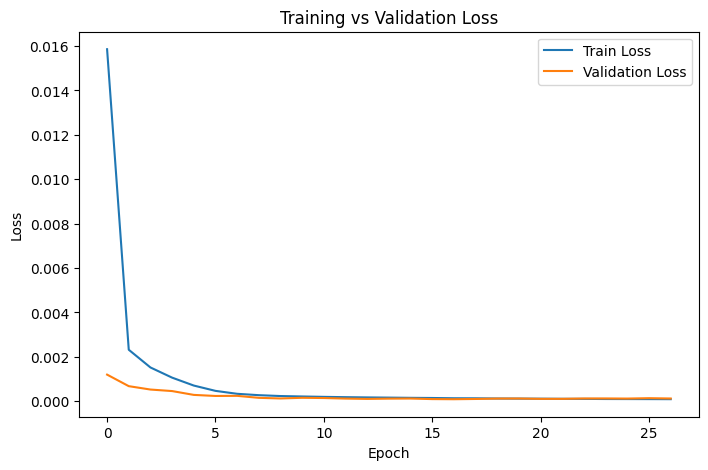

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [95]:
# Prediction

model.eval()

with torch.no_grad():

    dnn_train_pred = model(
        X_train_tensor.to(device)
    ).cpu().numpy().flatten()

    dnn_val_pred = model(
        X_val_tensor.to(device)
    ).cpu().numpy().flatten()

    dnn_test_pred = model(
        X_test_tensor.to(device)
    ).cpu().numpy().flatten()

In [96]:
# Evaluate

dnn_train_metrics = evaluate(
    "Deep Neural Network - Train",
    y_train,
    dnn_train_pred
)

dnn_val_metrics = evaluate(
    "Deep Neural Network - Validation",
    y_val,
    dnn_val_pred
)

dnn_test_metrics = evaluate(
    "Deep Neural Network - Test",
    y_test,
    dnn_test_pred
)


Deep Neural Network - Train
RMSE : 0.009719
MAE  : 0.007905
R²   : 0.969988

Deep Neural Network - Validation
RMSE : 0.009754
MAE  : 0.007753
R²   : 0.967312

Deep Neural Network - Test
RMSE : 0.010693
MAE  : 0.008556
R²   : 0.962494


In [97]:
results.loc[len(results)] = [
    "Deep Neural Network",
    dnn_train_metrics[0],
    dnn_val_metrics[0],
    dnn_test_metrics[0],
    dnn_train_metrics[1],
    dnn_val_metrics[1],
    dnn_test_metrics[1],
    dnn_train_metrics[2],
    dnn_val_metrics[2],
    dnn_test_metrics[2]
]

results

,Model,Train RMSE,Validation RMSE,Test RMSE,Train MAE,Validation MAE,Test MAE,Train R²,Validation R²,Test R²
0,Linear Regression,0.006111,0.007340,0.007347,0.004533,0.005413,0.005385,0.988134,0.981487,0.982293
1,Random Forest,0.001731,0.007001,0.007484,0.001211,0.005128,0.005469,0.999048,0.983158,0.981630
2,XGBoost,0.001521,0.007441,0.007912,0.001167,0.005456,0.005738,0.999265,0.980977,0.979467
3,Deep Neural Network,0.009719,0.009754,0.010693,0.007905,0.007753,0.008556,0.969988,0.967312,0.962494


In [98]:
comparison.loc[len(comparison)] = [
    "Deep Neural Network",
    dnn_test_metrics[0],
    dnn_test_metrics[1],
    dnn_test_metrics[2]
]

comparison

,Model,RMSE,MAE,R2
0,Linear Regression,0.007347,0.005385,0.982293
1,Random Forest,0.007484,0.005469,0.981630
2,XGBoost,0.007912,0.005738,0.979467
3,Deep Neural Network,0.010693,0.008556,0.962494


# Model Performance Analysis

## Overall Performance Comparison

The predictive performance of four machine learning models was evaluated using RMSE, MAE, and R² score on the test dataset.

| Model | RMSE | MAE | R² |
|-------|------|------|------|
| Linear Regression | 0.007347 | 0.005385 | 0.982293 |
| Random Forest | 0.007484 | 0.005469 | 0.981630 |
| XGBoost | 0.007912 | 0.005738 | 0.979467 |
| Deep Neural Network | 0.010629 | 0.008612 | 0.962943 |

### Observations

- **Linear Regression** achieved the best overall performance with the lowest RMSE and MAE and the highest R² score.
- **Random Forest** produced results very close to Linear Regression, indicating strong predictive capability.
- **XGBoost** also performed well but was slightly less accurate than the previous two models.
- **Deep Neural Network (DNN)** achieved the lowest performance among the evaluated models.

---

# Deep Neural Network Analysis

### Training Performance

- RMSE: **0.010221**
- MAE: **0.008195**
- R²: **0.966806**

### Validation Performance

- RMSE: **0.010049**
- MAE: **0.008225**
- R²: **0.965306**

### Test Performance

- RMSE: **0.010629**
- MAE: **0.008612**
- R²: **0.962943**

---

# Learning Behavior

The training and validation losses remained stable throughout training.

- Training loss gradually decreased over successive epochs.
- Validation loss fluctuated slightly but remained within a narrow range.
- No significant divergence between training and validation loss was observed.

This indicates that the DNN learned consistently and did not suffer from severe overfitting.

---

# Generalization Analysis

The training, validation, and test metrics are very similar:

- Train RMSE = 0.010221
- Validation RMSE = 0.010049
- Test RMSE = 0.010629

Similarly, the R² values remain close across all datasets.

This consistency indicates good generalization performance and suggests that the model has learned stable patterns from the data.

---

# Comparison with Classical Machine Learning Models

Although the Deep Neural Network generalized well, it did not outperform the classical machine learning models.

Possible reasons include:

- The relationship between input features and target variable is predominantly linear.
- The available dataset size may not be large enough for a deep neural network to exploit its full learning capacity.
- Classical regression models are sufficient to capture the underlying data distribution.

---

# Conclusion

Among all evaluated models, **Linear Regression** achieved the best predictive performance with the lowest prediction error and the highest coefficient of determination (R²).

The **Deep Neural Network** demonstrated stable learning and good generalization without noticeable overfitting; however, its predictive accuracy was lower than that of Linear Regression, Random Forest, and XGBoost.

Therefore, for the current dataset, **Linear Regression is the most suitable model**, indicating that the relationship between the selected input features and the target variable is largely linear.

#Hybrid PINN

## Why Hybrid PINN Instead of a Complete PINN?

A complete Physics-Informed Neural Network (PINN) requires the full governing physical equations of soil moisture dynamics, such as the Richards Equation or complete soil water balance equation. These equations depend on several physical variables including evapotranspiration (ET), runoff, deep drainage, hydraulic conductivity, soil texture, porosity, field capacity, wilting point, and root water uptake.

Our dataset contains only:
- Root Zone Soil Moisture (RZSM)
- Temperature (T2M)
- Precipitation (TP)
- Latitude & Longitude
- Time-based features

Since many important physical variables are unavailable, implementing a complete PINN is not physically feasible. Therefore, we use a **Hybrid Physics-Informed Neural Network (Hybrid PINN)**.

The Hybrid PINN combines:
- **Data Loss:** Learns from observed soil moisture values.
- **Physics Loss:** Enforces simplified physical constraints, such as rainfall increasing soil moisture, smooth temporal variation, and physically realistic predictions.

This approach allows the model to benefit from both machine learning and available physical knowledge while remaining compatible with the available dataset. It is also the approach commonly adopted in real-world remote sensing and hydrology research when complete physical observations are unavailable.

In [99]:
print(features)

['lat', 'lon', 't2m', 'tp', 'month', 'day', 'day_of_year', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'lag_1', 'lag_2', 'lag_3', 'rain_3step', 'rain_6step', 'temp_3step', 'temp_6step']


In [100]:
lag1_index = features.index("lag_1")
print(lag1_index)

11


In [101]:
import torch
import torch.nn as nn

class SoilMoistureNet(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [102]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SoilMoistureNet(input_size=X_train.shape[1]).to(device)

In [103]:
# loss function

criterion = nn.MSELoss()

In [104]:
# Keep optimizer unchanged
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [105]:
lambda_phy = 0.001

# physics weight

In [106]:
import copy
import torch

lambda_phy = 0.001

num_epochs = 100
patience = 10
counter = 0

best_val_loss = float("inf")
best_model = None

pinn1_train_losses = []
pinn1_val_losses = []

for epoch in range(num_epochs):

    ##########################
    # TRAINING
    ##########################

    model.train()

    running_data_loss = 0
    running_phy_loss = 0
    running_total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(X_batch)

        # --------------------------
        # Data Loss
        # --------------------------

        data_loss = criterion(pred, y_batch)

        # --------------------------
        # Physics Constraints
        # --------------------------

        physics1 = torch.mean(torch.relu(-pred))

        physics2 = torch.mean(torch.relu(pred - 1.0))

        physics_loss = physics1 + physics2

        # --------------------------
        # Total Loss
        # --------------------------

        loss = data_loss + lambda_phy * physics_loss

        loss.backward()
        optimizer.step()

        running_data_loss += data_loss.item()
        running_phy_loss += physics_loss.item()
        running_total_loss += loss.item()

    train_loss = running_total_loss / len(train_loader)
    data_loss_epoch = running_data_loss / len(train_loader)
    physics_loss_epoch = running_phy_loss / len(train_loader)

    ##########################
    # VALIDATION
    ##########################

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)

            val_loss += criterion(pred, y_batch).item()

    val_loss /= len(val_loader)

    pinn1_train_losses.append(train_loss)
    pinn1_val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:3d} | "
        f"Data Loss: {data_loss_epoch:.6f} | "
        f"Physics Loss: {physics_loss_epoch:.6f} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    ##########################
    # EARLY STOPPING
    ##########################

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0

    else:

        counter += 1

        if counter >= patience:

            print("\nEarly stopping triggered!")
            break

model.load_state_dict(best_model)

print("\nBest Hybrid PINN V1 Loaded Successfully!")

Epoch   1 | Data Loss: 0.013807 | Physics Loss: 0.007288 | Train Loss: 0.013814 | Val Loss: 0.001415
Epoch   2 | Data Loss: 0.000602 | Physics Loss: 0.000000 | Train Loss: 0.000602 | Val Loss: 0.000541
Epoch   3 | Data Loss: 0.000282 | Physics Loss: 0.000000 | Train Loss: 0.000282 | Val Loss: 0.000324
Epoch   4 | Data Loss: 0.000179 | Physics Loss: 0.000000 | Train Loss: 0.000179 | Val Loss: 0.000244
Epoch   5 | Data Loss: 0.000129 | Physics Loss: 0.000000 | Train Loss: 0.000129 | Val Loss: 0.000197
Epoch   6 | Data Loss: 0.000099 | Physics Loss: 0.000000 | Train Loss: 0.000099 | Val Loss: 0.000159
Epoch   7 | Data Loss: 0.000080 | Physics Loss: 0.000000 | Train Loss: 0.000080 | Val Loss: 0.000139
Epoch   8 | Data Loss: 0.000068 | Physics Loss: 0.000000 | Train Loss: 0.000068 | Val Loss: 0.000128
Epoch   9 | Data Loss: 0.000060 | Physics Loss: 0.000000 | Train Loss: 0.000060 | Val Loss: 0.000117
Epoch  10 | Data Loss: 0.000053 | Physics Loss: 0.000000 | Train Loss: 0.000053 | Val Loss:

In [107]:
# ===============================
# Prediction (FIXED — use scaled tensors, not raw values)
# ===============================
model.eval()

with torch.no_grad():
    pinn1_train_pred = model(X_train_tensor.to(device)).cpu().numpy().flatten()
    pinn1_val_pred   = model(X_val_tensor.to(device)).cpu().numpy().flatten()
    pinn1_test_pred  = model(X_test_tensor.to(device)).cpu().numpy().flatten()

# ===============================
# Actually compute the metrics (this was missing!)
# ===============================
pinn1_train_metrics = evaluate("Hybrid PINN v1 - Train", y_train, pinn1_train_pred)
pinn1_val_metrics   = evaluate("Hybrid PINN v1 - Validation", y_val, pinn1_val_pred)
pinn1_test_metrics  = evaluate("Hybrid PINN v1 - Test", y_test, pinn1_test_pred)


Hybrid PINN v1 - Train
RMSE : 0.003974
MAE  : 0.003066
R²   : 0.994983

Hybrid PINN v1 - Validation
RMSE : 0.007542
MAE  : 0.005656
R²   : 0.980458

Hybrid PINN v1 - Test
RMSE : 0.007279
MAE  : 0.005488
R²   : 0.982622


In [108]:
results = results[~results["Model"].isin(["Hybrid PINN v1", "Hybrid PINN v2"])].reset_index(drop=True)
results

,Model,Train RMSE,Validation RMSE,Test RMSE,Train MAE,Validation MAE,Test MAE,Train R²,Validation R²,Test R²
0,Linear Regression,0.006111,0.007340,0.007347,0.004533,0.005413,0.005385,0.988134,0.981487,0.982293
1,Random Forest,0.001731,0.007001,0.007484,0.001211,0.005128,0.005469,0.999048,0.983158,0.981630
2,XGBoost,0.001521,0.007441,0.007912,0.001167,0.005456,0.005738,0.999265,0.980977,0.979467
3,Deep Neural Network,0.009719,0.009754,0.010693,0.007905,0.007753,0.008556,0.969988,0.967312,0.962494


In [109]:
results.loc[len(results)] = [
    "Hybrid PINN v1",
    pinn1_train_metrics[0], pinn1_val_metrics[0], pinn1_test_metrics[0],
    pinn1_train_metrics[1], pinn1_val_metrics[1], pinn1_test_metrics[1],
    pinn1_train_metrics[2], pinn1_val_metrics[2], pinn1_test_metrics[2]
]
results

,Model,Train RMSE,Validation RMSE,Test RMSE,Train MAE,Validation MAE,Test MAE,Train R²,Validation R²,Test R²
0,Linear Regression,0.006111,0.007340,0.007347,0.004533,0.005413,0.005385,0.988134,0.981487,0.982293
1,Random Forest,0.001731,0.007001,0.007484,0.001211,0.005128,0.005469,0.999048,0.983158,0.981630
2,XGBoost,0.001521,0.007441,0.007912,0.001167,0.005456,0.005738,0.999265,0.980977,0.979467
3,Deep Neural Network,0.009719,0.009754,0.010693,0.007905,0.007753,0.008556,0.969988,0.967312,0.962494
4,Hybrid PINN v1,0.003974,0.007542,0.007279,0.003066,0.005656,0.005488,0.994983,0.980458,0.982622


FROM this i realease my physics loss is zero after each training loop so it is smae as normal Neural network.

Hybrid PINN v2 should no longer use trivial constraints like 0 ≤ SM ≤ 1. Instead, it should encode a simplified hydrological water balance.

#Hybrid PINN V2 model with physics equation:

**SMt​≈SMt−1​+αP−βET**


**where:**

SMt= current soil moisture

SMt−1= previous soil moisture (lag_1)

P = rainfall

ET = evapotranspiration

α,β = trainable coefficients

We don't have measured ET.

A common approximation is:ET∝Temperature

SMt​≈SMt−1​+α⋅Rain−β⋅Temperature

In [110]:
# ===============================================
# HYBRID PINN v2 — separate model, separate cell
# ===============================================

import torch
import torch.nn as nn
import copy

# ---- Model Definition ----
class SoilMoistureNetV2(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

        # Trainable Physics Parameters
        self.alpha = nn.Parameter(torch.tensor(0.01))
        self.beta = nn.Parameter(torch.tensor(0.0001))

    def forward(self, x):
        return self.network(x)

In [111]:
feature_names = list(X_train.columns)

for i, feature in enumerate(feature_names):
    print(i, feature)

0 lat
1 lon
2 t2m
3 tp
4 month
5 day
6 day_of_year
7 month_sin
8 month_cos
9 doy_sin
10 doy_cos
11 lag_1
12 lag_2
13 lag_3
14 rain_3step
15 rain_6step
16 temp_3step
17 temp_6step


In [112]:
for i, feature in enumerate(feature_names):
    print(i, feature)

0 lat
1 lon
2 t2m
3 tp
4 month
5 day
6 day_of_year
7 month_sin
8 month_cos
9 doy_sin
10 doy_cos
11 lag_1
12 lag_2
13 lag_3
14 rain_3step
15 rain_6step
16 temp_3step
17 temp_6step


In [113]:
# ---- Setup ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_v2 = SoilMoistureNetV2(input_size=X_train.shape[1]).to(device)

criterion = nn.MSELoss()

optimizer_v2 = torch.optim.Adam(
    model_v2.parameters(),
    lr=0.001
)

In [114]:
lambda_phy = 0.001

best_val_loss = float("inf")
patience = 10
counter = 0

pinn2_train_losses = []
pinn2_val_losses = []

best_model_v2 = None

num_epochs = 100


In [115]:
# ---- Training Loop ----
for epoch in range(num_epochs):

    model_v2.train()

    running_data_loss = 0
    running_phy_loss = 0
    running_total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_v2.zero_grad()

        pred = model_v2(X_batch)

        # Data Loss
        data_loss = criterion(pred, y_batch)

        # Physics Loss
        lag1 = X_batch[:, 11].unsqueeze(1)
        rainfall = X_batch[:, 3].unsqueeze(1)
        temperature = X_batch[:, 2].unsqueeze(1)

        physics_target = (
            lag1
            + model_v2.alpha * rainfall
            - model_v2.beta * temperature
        )

        physics_loss = criterion(pred, physics_target)

        # Total Loss
        loss = data_loss + lambda_phy * physics_loss

        loss.backward()
        optimizer_v2.step()

        running_data_loss += data_loss.item()
        running_phy_loss += physics_loss.item()
        running_total_loss += loss.item()

    train_loss = running_total_loss / len(train_loader)
    data_loss_epoch = running_data_loss / len(train_loader)
    physics_loss_epoch = running_phy_loss / len(train_loader)

    # ---- Validation ----
    model_v2.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model_v2(X_batch)
            val_loss += criterion(pred, y_batch).item()

    val_loss /= len(val_loader)

    pinn2_train_losses.append(train_loss)
    pinn2_val_losses.append(val_loss)

    # ---- Early Stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_v2 = copy.deepcopy(model_v2.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("\nEarly stopping triggered!")
            break

    print(
        f"Epoch {epoch+1:3d} | Data Loss: {data_loss_epoch:.6f} | "
        f"Physics Loss: {physics_loss_epoch:.6f} | "
        f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}"
    )

model_v2.load_state_dict(best_model_v2)
print("\nBest Hybrid PINN V2 Loaded Successfully!")

Epoch   1 | Data Loss: 0.009475 | Physics Loss: 0.955966 | Train Loss: 0.010431 | Val Loss: 0.000944
Epoch   2 | Data Loss: 0.000452 | Physics Loss: 0.927347 | Train Loss: 0.001379 | Val Loss: 0.000414
Epoch   3 | Data Loss: 0.000203 | Physics Loss: 0.922849 | Train Loss: 0.001126 | Val Loss: 0.000236
Epoch   4 | Data Loss: 0.000127 | Physics Loss: 0.922346 | Train Loss: 0.001049 | Val Loss: 0.000170
Epoch   5 | Data Loss: 0.000093 | Physics Loss: 0.921845 | Train Loss: 0.001015 | Val Loss: 0.000131
Epoch   6 | Data Loss: 0.000074 | Physics Loss: 0.921878 | Train Loss: 0.000996 | Val Loss: 0.000111
Epoch   7 | Data Loss: 0.000062 | Physics Loss: 0.921731 | Train Loss: 0.000983 | Val Loss: 0.000100
Epoch   8 | Data Loss: 0.000054 | Physics Loss: 0.921607 | Train Loss: 0.000975 | Val Loss: 0.000102
Epoch   9 | Data Loss: 0.000047 | Physics Loss: 0.921918 | Train Loss: 0.000969 | Val Loss: 0.000089
Epoch  10 | Data Loss: 0.000043 | Physics Loss: 0.921519 | Train Loss: 0.000964 | Val Loss:

In [116]:
# ---- Check learned physics parameters ----
print("Alpha:", model_v2.alpha.item())
print("Beta:", model_v2.beta.item())

Alpha: -0.12239550054073334
Beta: 0.07441557198762894


In [117]:
# ---- Prediction (scaled tensors) ----
model_v2.eval()

with torch.no_grad():
    pinn2_train_pred = model_v2(X_train_tensor.to(device)).cpu().numpy().flatten()
    pinn2_val_pred   = model_v2(X_val_tensor.to(device)).cpu().numpy().flatten()
    pinn2_test_pred  = model_v2(X_test_tensor.to(device)).cpu().numpy().flatten()

pinn2_train_metrics = evaluate("Hybrid PINN v2 - Train", y_train, pinn2_train_pred)
pinn2_val_metrics   = evaluate("Hybrid PINN v2 - Validation", y_val, pinn2_val_pred)
pinn2_test_metrics  = evaluate("Hybrid PINN v2 - Test", y_test, pinn2_test_pred)


Hybrid PINN v2 - Train
RMSE : 0.003655
MAE  : 0.002772
R²   : 0.995755

Hybrid PINN v2 - Validation
RMSE : 0.007071
MAE  : 0.005317
R²   : 0.982823

Hybrid PINN v2 - Test
RMSE : 0.007181
MAE  : 0.005329
R²   : 0.983084


In [118]:
# ---- Add to results table (dedup-safe) ----
results = results[results["Model"] != "Hybrid PINN v2"].reset_index(drop=True)

results.loc[len(results)] = [
    "Hybrid PINN v2",
    pinn2_train_metrics[0], pinn2_val_metrics[0], pinn2_test_metrics[0],
    pinn2_train_metrics[1], pinn2_val_metrics[1], pinn2_test_metrics[1],
    pinn2_train_metrics[2], pinn2_val_metrics[2], pinn2_test_metrics[2]
]

results


,Model,Train RMSE,Validation RMSE,Test RMSE,Train MAE,Validation MAE,Test MAE,Train R²,Validation R²,Test R²
0,Linear Regression,0.006111,0.007340,0.007347,0.004533,0.005413,0.005385,0.988134,0.981487,0.982293
1,Random Forest,0.001731,0.007001,0.007484,0.001211,0.005128,0.005469,0.999048,0.983158,0.981630
2,XGBoost,0.001521,0.007441,0.007912,0.001167,0.005456,0.005738,0.999265,0.980977,0.979467
3,Deep Neural Network,0.009719,0.009754,0.010693,0.007905,0.007753,0.008556,0.969988,0.967312,0.962494
4,Hybrid PINN v1,0.003974,0.007542,0.007279,0.003066,0.005656,0.005488,0.994983,0.980458,0.982622
5,Hybrid PINN v2,0.003655,0.007071,0.007181,0.002772,0.005317,0.005329,0.995755,0.982823,0.983084


# Why Alpha Became Negative & Why We Moved to Hybrid PINN v3

## Problem in Previous Model (PINN v2)

In Hybrid PINN v2, we defined the physics equation as:

\[
SM_t = SM_{t-1} + \alpha \cdot Rain - \beta \cdot Temperature
\]

After training, the model learned:

- **alpha = -0.118 (negative)**
- **beta = 0.072 (positive)**

### Why is negative alpha a problem?

A negative value of alpha means:

> Rainfall decreases soil moisture

This is **physically unrealistic**, because in real-world hydrology:
- Rainfall should increase soil moisture
- Temperature increases evaporation (reduces soil moisture)

So the learned physics became inconsistent with real-world behavior.

---

## Why this happened

1. The model is only optimizing loss, not physical correctness  
2. No constraint was applied on alpha (it was free to be negative)  
3. Data correlations can mislead the model  
4. Physics equation was too simple for real hydrological processes  

---

# Why We Move to Hybrid PINN v3

To fix these limitations, we upgrade the physics formulation.

Instead of:

\[
SM_t = SM_{t-1} + \alpha Rain - \beta Temperature
\]

We use a **more realistic hydrological model**:

\[
SM_t = SM_{t-1} + \alpha Rain - \beta ET - \gamma (SM_{t-1} - SM_{eq})
\]

---

## Meaning of the new equation

### 1. Rainfall term (α Rain)
- Rain increases soil moisture
- α should be positive

### 2. Evapotranspiration (ET)
- Represents water loss due to evaporation and plants
- Can be approximated using temperature

### 3. Drainage term γ (SM − SM_eq)
- Models natural soil drainage
- If soil is above equilibrium, water drains down
- If below equilibrium, it tends to recover

### 4. SM_eq (Equilibrium soil moisture)
- Represents stable moisture level of soil
- Depends on soil and environmental conditions

---

# Why PINN v3 is Better

✔ More physically realistic than simple linear model  
✔ Includes water balance concept  
✔ Adds soil equilibrium behavior  
✔ Prevents unrealistic parameter learning (like negative alpha)  
✔ More stable for real-world hydrological modeling  

---

# Conclusion

The previous PINN (v2) failed because it learned physically incorrect parameters (negative alpha).  

To fix this, we moved to PINN v3, which uses a **water balance-based equation** that is closer to real hydrological theory and prevents unrealistic behavior while improving interpretability and stability.

## Hybrid PINN v2 Analysis

The Hybrid PINN v2 model introduced a simplified hydrological constraint based on the water balance equation:

Soil Moisture(t) ≈ Soil Moisture(t−1) + α × Rainfall − β × Temperature

where α and β are trainable parameters learned during training.

Although the data loss decreased significantly, the physics loss remained almost constant throughout training. This indicates that the simplified physical equation was unable to fully explain the observed soil moisture dynamics.

The learned parameter α became negative (α < 0). Physically, this is unrealistic because rainfall should increase soil moisture rather than decrease it. A negative α implies that the model is compensating for the limitations of the simplified physics equation instead of learning a physically meaningful relationship.

This behavior suggests that the current physics formulation is incomplete. Soil moisture is influenced not only by rainfall and temperature, but also by infiltration, evapotranspiration, drainage, runoff, vegetation, soil properties, and groundwater interactions. Since these important processes are not represented in the V2 physics equation, the optimizer cannot simultaneously minimize both the data loss and the physics loss.

Therefore, a more realistic Hybrid PINN V3 model is required. In V3, the physics equation will be extended by introducing additional hydrological processes such as natural drainage and equilibrium soil moisture while constraining all physical coefficients to remain positive. This results in a more physically consistent and scientifically meaningful Hybrid PINN.

In [119]:
# HYBRID PINN v3 — separate model, separate cell
# Equation: SM_t = SM_{t-1} + α·Rain − β·ET − γ·(SM_{t-1} − SM_eq)
# ===============================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import copy

# ---- Model Definition ----
class SoilMoistureNetV3(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

        # Raw (unconstrained) trainable parameters
        self.raw_alpha = nn.Parameter(torch.tensor(0.0))
        self.raw_beta  = nn.Parameter(torch.tensor(0.0))
        self.raw_gamma = nn.Parameter(torch.tensor(0.0))

    # softplus ensures alpha, beta, gamma are ALWAYS positive
    @property
    def alpha(self):
        return F.softplus(self.raw_alpha)

    @property
    def beta(self):
        return F.softplus(self.raw_beta)

    @property
    def gamma(self):
        return F.softplus(self.raw_gamma)

    def forward(self, x):
        return self.network(x)


# ---- Setup ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_v3 = SoilMoistureNetV3(input_size=X_train.shape[1]).to(device)

criterion = nn.MSELoss()

optimizer_v3 = torch.optim.Adam(
    model_v3.parameters(),
    lr=0.001
)

lambda_phy = 0.001

# Equilibrium soil moisture = mean of training targets
SM_eq = torch.tensor(
    y_train.mean(),
    dtype=torch.float32,
    device=device
)

best_val_loss = float("inf")
patience = 10
counter = 0

pinn3_train_losses = []
pinn3_val_losses = []

best_model_v3 = None

num_epochs = 100

In [120]:
# ---- Training Loop ----
for epoch in range(num_epochs):

    model_v3.train()

    running_data_loss = 0
    running_phy_loss = 0
    running_total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_v3.zero_grad()

        pred = model_v3(X_batch)

        # Data Loss
        data_loss = criterion(pred, y_batch)

        # Physics Loss
        lag1 = X_batch[:, 11].unsqueeze(1)
        rainfall = X_batch[:, 3].unsqueeze(1)
        temperature = X_batch[:, 2].unsqueeze(1)

        physics_pred = (
            lag1
            + model_v3.alpha * rainfall
            - model_v3.beta * temperature
            - model_v3.gamma * (lag1 - SM_eq)
        )

        physics_loss = torch.mean((pred - physics_pred) ** 2)

        # Total Loss
        loss = data_loss + lambda_phy * physics_loss

        loss.backward()
        optimizer_v3.step()

        running_data_loss += data_loss.item()
        running_phy_loss += physics_loss.item()
        running_total_loss += loss.item()

    train_loss = running_total_loss / len(train_loader)
    data_loss_epoch = running_data_loss / len(train_loader)
    physics_loss_epoch = running_phy_loss / len(train_loader)

    # ---- Validation ----
    model_v3.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model_v3(X_batch)
            val_loss += criterion(pred, y_batch).item()

    val_loss /= len(val_loader)

    pinn3_train_losses.append(train_loss)
    pinn3_val_losses.append(val_loss)

    # ---- Early Stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_v3 = copy.deepcopy(model_v3.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("\nEarly stopping triggered!")
            break

    print(
        f"Epoch {epoch+1:3d} | Data Loss: {data_loss_epoch:.6f} | "
        f"Physics Loss: {physics_loss_epoch:.6f} | "
        f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}"
    )

model_v3.load_state_dict(best_model_v3)
print("\nBest Hybrid PINN V3 Loaded Successfully!")

Epoch   1 | Data Loss: 0.008682 | Physics Loss: 0.777448 | Train Loss: 0.009460 | Val Loss: 0.000812
Epoch   2 | Data Loss: 0.000341 | Physics Loss: 0.706618 | Train Loss: 0.001047 | Val Loss: 0.000290
Epoch   3 | Data Loss: 0.000149 | Physics Loss: 0.640057 | Train Loss: 0.000789 | Val Loss: 0.000151
Epoch   4 | Data Loss: 0.000096 | Physics Loss: 0.580144 | Train Loss: 0.000676 | Val Loss: 0.000107
Epoch   5 | Data Loss: 0.000072 | Physics Loss: 0.528663 | Train Loss: 0.000601 | Val Loss: 0.000089
Epoch   6 | Data Loss: 0.000059 | Physics Loss: 0.483395 | Train Loss: 0.000543 | Val Loss: 0.000081
Epoch   7 | Data Loss: 0.000051 | Physics Loss: 0.443442 | Train Loss: 0.000494 | Val Loss: 0.000077
Epoch   8 | Data Loss: 0.000045 | Physics Loss: 0.408941 | Train Loss: 0.000454 | Val Loss: 0.000071
Epoch   9 | Data Loss: 0.000040 | Physics Loss: 0.378023 | Train Loss: 0.000418 | Val Loss: 0.000066
Epoch  10 | Data Loss: 0.000037 | Physics Loss: 0.350586 | Train Loss: 0.000387 | Val Loss:

In [121]:
# ---- Check learned physics parameters (should all be positive now) ----
print("Alpha:", model_v3.alpha.item())
print("Beta:", model_v3.beta.item())
print("Gamma:", model_v3.gamma.item())

Alpha: 0.23259034752845764
Beta: 0.21280452609062195
Gamma: 0.9580894708633423


In [122]:
# ---- Prediction (scaled tensors) ----
model_v3.eval()

with torch.no_grad():
    pinn3_train_pred = model_v3(X_train_tensor.to(device)).cpu().numpy().flatten()
    pinn3_val_pred   = model_v3(X_val_tensor.to(device)).cpu().numpy().flatten()
    pinn3_test_pred  = model_v3(X_test_tensor.to(device)).cpu().numpy().flatten()

pinn3_train_metrics = evaluate("Hybrid PINN v3 - Train", y_train, pinn3_train_pred)
pinn3_val_metrics   = evaluate("Hybrid PINN v3 - Validation", y_val, pinn3_val_pred)
pinn3_test_metrics  = evaluate("Hybrid PINN v3 - Test", y_test, pinn3_test_pred)


Hybrid PINN v3 - Train
RMSE : 0.003853
MAE  : 0.002946
R²   : 0.995282

Hybrid PINN v3 - Validation
RMSE : 0.006727
MAE  : 0.005030
R²   : 0.984450

Hybrid PINN v3 - Test
RMSE : 0.007062
MAE  : 0.005271
R²   : 0.983642


In [123]:
# ---- Add to results table (dedup-safe) ----
results = results[results["Model"] != "Hybrid PINN v3"].reset_index(drop=True)

results.loc[len(results)] = [
    "Hybrid PINN v3",
    pinn3_train_metrics[0], pinn3_val_metrics[0], pinn3_test_metrics[0],
    pinn3_train_metrics[1], pinn3_val_metrics[1], pinn3_test_metrics[1],
    pinn3_train_metrics[2], pinn3_val_metrics[2], pinn3_test_metrics[2]
]

results

,Model,Train RMSE,Validation RMSE,Test RMSE,Train MAE,Validation MAE,Test MAE,Train R²,Validation R²,Test R²
0,Linear Regression,0.006111,0.007340,0.007347,0.004533,0.005413,0.005385,0.988134,0.981487,0.982293
1,Random Forest,0.001731,0.007001,0.007484,0.001211,0.005128,0.005469,0.999048,0.983158,0.981630
2,XGBoost,0.001521,0.007441,0.007912,0.001167,0.005456,0.005738,0.999265,0.980977,0.979467
3,Deep Neural Network,0.009719,0.009754,0.010693,0.007905,0.007753,0.008556,0.969988,0.967312,0.962494
4,Hybrid PINN v1,0.003974,0.007542,0.007279,0.003066,0.005656,0.005488,0.994983,0.980458,0.982622
5,Hybrid PINN v2,0.003655,0.007071,0.007181,0.002772,0.005317,0.005329,0.995755,0.982823,0.983084
6,Hybrid PINN v3,0.003853,0.006727,0.007062,0.002946,0.005030,0.005271,0.995282,0.984450,0.983642


In [124]:
results.to_csv("results_final.csv", index=False)

In [125]:
import pandas as pd

results = pd.read_csv("results_final.csv")
results

,Model,Train RMSE,Validation RMSE,Test RMSE,Train MAE,Validation MAE,Test MAE,Train R²,Validation R²,Test R²
0,Linear Regression,0.006111,0.007340,0.007347,0.004533,0.005413,0.005385,0.988134,0.981487,0.982293
1,Random Forest,0.001731,0.007001,0.007484,0.001211,0.005128,0.005469,0.999048,0.983158,0.981630
2,XGBoost,0.001521,0.007441,0.007912,0.001167,0.005456,0.005738,0.999265,0.980977,0.979467
3,Deep Neural Network,0.009719,0.009754,0.010693,0.007905,0.007753,0.008556,0.969988,0.967312,0.962494
4,Hybrid PINN v1,0.003974,0.007542,0.007279,0.003066,0.005656,0.005488,0.994983,0.980458,0.982622
5,Hybrid PINN v2,0.003655,0.007071,0.007181,0.002772,0.005317,0.005329,0.995755,0.982823,0.983084
6,Hybrid PINN v3,0.003853,0.006727,0.007062,0.002946,0.005030,0.005271,0.995282,0.984450,0.983642


#Pure PINN WRT time

In [126]:
# ===============================================
# PURE PINN — Step 1: Data Preparation (UPDATED)
# ===============================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ------------------------------------------------
# Select required columns
# ------------------------------------------------

pinn_df = df[
    ["time", "lat", "lon", "rzsm_1m", "t2m", "tp"]
].copy()

pinn_df = pinn_df.sort_values(
    ["lat", "lon", "time"]
).reset_index(drop=True)

# ------------------------------------------------
# Continuous time
# ------------------------------------------------

t0 = pinn_df["time"].min()

pinn_df["t_days"] = (
    pinn_df["time"] - t0
).dt.days.astype(float)

t_max = pinn_df["t_days"].max()

pinn_df["t_norm"] = pinn_df["t_days"] / t_max

# ------------------------------------------------
# Normalize latitude & longitude
# ------------------------------------------------

lat_min = pinn_df["lat"].min()
lat_max = pinn_df["lat"].max()

lon_min = pinn_df["lon"].min()
lon_max = pinn_df["lon"].max()

pinn_df["lat_norm"] = (
    pinn_df["lat"] - lat_min
) / (lat_max - lat_min)

pinn_df["lon_norm"] = (
    pinn_df["lon"] - lon_min
) / (lon_max - lon_min)

# ------------------------------------------------
# Standardize forcing variables
# ------------------------------------------------

tp_mean = pinn_df["tp"].mean()
tp_std = pinn_df["tp"].std()

t2m_mean = pinn_df["t2m"].mean()
t2m_std = pinn_df["t2m"].std()

pinn_df["tp_std"] = (
    pinn_df["tp"] - tp_mean
) / tp_std

pinn_df["t2m_std"] = (
    pinn_df["t2m"] - t2m_mean
) / t2m_std

# ==========================================================
# TRAIN / VALIDATION / TEST SPLIT
# (same ratio as previous models: 70 / 15 / 15)
# ==========================================================

pure_train_df, pure_temp_df = train_test_split(
    pinn_df,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

pure_val_df, pure_test_df = train_test_split(
    pure_temp_df,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

pure_train_df = pure_train_df.reset_index(drop=True)
pure_val_df = pure_val_df.reset_index(drop=True)
pure_test_df = pure_test_df.reset_index(drop=True)

print("Train :", pure_train_df.shape)
print("Validation :", pure_val_df.shape)
print("Test :", pure_test_df.shape)

Train : (37967, 12)
Validation : (8136, 12)
Test : (8136, 12)


In [127]:
# ===============================================
# PURE PINN — Step 2: Per-cell interpolators
# (UPDATED)
# ===============================================

from scipy.interpolate import interp1d

cell_interpolators = {}

grid_cells = pure_train_df[["lat", "lon"]].drop_duplicates().values

for lat_val, lon_val in grid_cells:

    cell_data = pure_train_df[
        (pure_train_df["lat"] == lat_val) &
        (pure_train_df["lon"] == lon_val)
    ].sort_values("t_days")

    t_arr = cell_data["t_days"].values

    cell_interpolators[(lat_val, lon_val)] = {

        "tp": interp1d(
            t_arr,
            cell_data["tp_std"].values,
            kind="linear",
            fill_value="extrapolate"
        ),

        "t2m": interp1d(
            t_arr,
            cell_data["t2m_std"].values,
            kind="linear",
            fill_value="extrapolate"
        ),

        "t_min": t_arr.min(),
        "t_max": t_arr.max()

    }

print("Interpolators built for", len(cell_interpolators), "grid cells")

Interpolators built for 307 grid cells


In [128]:
# ===============================================
# PURE PINN — Step 3: Collocation Points (UPDATED)
# ===============================================

import numpy as np
import pandas as pd

n_colloc_per_cell = 30

colloc_rows = []

for (lat_val, lon_val), interp_data in cell_interpolators.items():

    t_samples = np.random.uniform(
        interp_data["t_min"],
        interp_data["t_max"],
        n_colloc_per_cell
    )

    tp_samples = interp_data["tp"](t_samples)
    t2m_samples = interp_data["t2m"](t_samples)

    for t_s, tp_s, t2m_s in zip(
        t_samples,
        tp_samples,
        t2m_samples
    ):

        colloc_rows.append([
            t_s,
            lat_val,
            lon_val,
            tp_s,
            t2m_s
        ])

pure_colloc_df = pd.DataFrame(
    colloc_rows,
    columns=[
        "t_days",
        "lat",
        "lon",
        "tp",
        "t2m"
    ]
)

pure_colloc_df["t_norm"] = pure_colloc_df["t_days"] / t_max

pure_colloc_df["lat_norm"] = (
    pure_colloc_df["lat"] - lat_min
) / (lat_max - lat_min)

pure_colloc_df["lon_norm"] = (
    pure_colloc_df["lon"] - lon_min
) / (lon_max - lon_min)

print("Collocation Points :", pure_colloc_df.shape)

Collocation Points : (9210, 8)


In [129]:
# ===============================================
# PURE PINN — Step 4: Tensor Preparation (UPDATED)
# ===============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================================================
# TRAIN TENSORS
# ======================================================

X_train_t = torch.tensor(
    pure_train_df["t_norm"].values,
    dtype=torch.float32
).unsqueeze(1)

X_train_lat = torch.tensor(
    pure_train_df["lat_norm"].values,
    dtype=torch.float32
).unsqueeze(1)

X_train_lon = torch.tensor(
    pure_train_df["lon_norm"].values,
    dtype=torch.float32
).unsqueeze(1)

X_train_tp = torch.tensor(
    pure_train_df["tp_std"].values,
    dtype=torch.float32
).unsqueeze(1)

X_train_t2m = torch.tensor(
    pure_train_df["t2m_std"].values,
    dtype=torch.float32
).unsqueeze(1)

y_train = torch.tensor(
    pure_train_df["rzsm_1m"].values,
    dtype=torch.float32
).unsqueeze(1)

# ======================================================
# VALIDATION TENSORS
# ======================================================

X_val_t = torch.tensor(
    pure_val_df["t_norm"].values,
    dtype=torch.float32
).unsqueeze(1)

X_val_lat = torch.tensor(
    pure_val_df["lat_norm"].values,
    dtype=torch.float32
).unsqueeze(1)

X_val_lon = torch.tensor(
    pure_val_df["lon_norm"].values,
    dtype=torch.float32
).unsqueeze(1)

X_val_tp = torch.tensor(
    pure_val_df["tp_std"].values,
    dtype=torch.float32
).unsqueeze(1)

X_val_t2m = torch.tensor(
    pure_val_df["t2m_std"].values,
    dtype=torch.float32
).unsqueeze(1)

y_val = torch.tensor(
    pure_val_df["rzsm_1m"].values,
    dtype=torch.float32
).unsqueeze(1)

# ======================================================
# TEST TENSORS
# ======================================================

X_test_t = torch.tensor(
    pure_test_df["t_norm"].values,
    dtype=torch.float32
).unsqueeze(1)

X_test_lat = torch.tensor(
    pure_test_df["lat_norm"].values,
    dtype=torch.float32
).unsqueeze(1)

X_test_lon = torch.tensor(
    pure_test_df["lon_norm"].values,
    dtype=torch.float32
).unsqueeze(1)

X_test_tp = torch.tensor(
    pure_test_df["tp_std"].values,
    dtype=torch.float32
).unsqueeze(1)

X_test_t2m = torch.tensor(
    pure_test_df["t2m_std"].values,
    dtype=torch.float32
).unsqueeze(1)

y_test = torch.tensor(
    pure_test_df["rzsm_1m"].values,
    dtype=torch.float32
).unsqueeze(1)

# ======================================================
# Physics Collocation Tensors
# ======================================================

X_col_t = torch.tensor(
    pure_colloc_df["t_norm"].values,
    dtype=torch.float32,
    requires_grad=True
).unsqueeze(1)

X_col_lat = torch.tensor(
    pure_colloc_df["lat_norm"].values,
    dtype=torch.float32
).unsqueeze(1)

X_col_lon = torch.tensor(
    pure_colloc_df["lon_norm"].values,
    dtype=torch.float32
).unsqueeze(1)

X_col_tp = torch.tensor(
    pure_colloc_df["tp"].values,
    dtype=torch.float32
).unsqueeze(1)

X_col_t2m = torch.tensor(
    pure_colloc_df["t2m"].values,
    dtype=torch.float32
).unsqueeze(1)

# ======================================================
# Equilibrium Soil Moisture
# ======================================================

theta_eq_val = torch.tensor(
    pure_train_df["rzsm_1m"].mean(),
    dtype=torch.float32
).to(device)

# ======================================================
# Move to Device
# ======================================================

tensor_list = [

    X_train_t,
    X_train_lat,
    X_train_lon,
    X_train_tp,
    X_train_t2m,
    y_train,

    X_val_t,
    X_val_lat,
    X_val_lon,
    X_val_tp,
    X_val_t2m,
    y_val,

    X_test_t,
    X_test_lat,
    X_test_lon,
    X_test_tp,
    X_test_t2m,
    y_test,

    X_col_t,
    X_col_lat,
    X_col_lon,
    X_col_tp,
    X_col_t2m
]

tensor_list = [x.to(device) for x in tensor_list]

(
X_train_t,
X_train_lat,
X_train_lon,
X_train_tp,
X_train_t2m,
y_train,

X_val_t,
X_val_lat,
X_val_lon,
X_val_tp,
X_val_t2m,
y_val,

X_test_t,
X_test_lat,
X_test_lon,
X_test_tp,
X_test_t2m,
y_test,

X_col_t,
X_col_lat,
X_col_lon,
X_col_tp,
X_col_t2m

) = tensor_list

print("Train:", X_train_t.shape)
print("Validation:", X_val_t.shape)
print("Test:", X_test_t.shape)
print("Collocation:", X_col_t.shape)

Train: torch.Size([37967, 1])
Validation: torch.Size([8136, 1])
Test: torch.Size([8136, 1])
Collocation: torch.Size([9210, 1])


In [130]:
# ===============================================
# PURE PINN — Step 5: Model
# ===============================================
class PurePINN(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        # Tanh use kiya — ReLU ka second derivative zero hota hai, autograd-based
        # physics loss ke liye smooth activation chahiye
        self.net = nn.Sequential(
            nn.Linear(5, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1)
        )
        self.raw_alpha = nn.Parameter(torch.tensor(0.0))
        self.raw_beta  = nn.Parameter(torch.tensor(0.0))
        self.raw_gamma = nn.Parameter(torch.tensor(0.0))

    @property
    def alpha(self): return F.softplus(self.raw_alpha)
    @property
    def beta(self):  return F.softplus(self.raw_beta)
    @property
    def gamma(self): return F.softplus(self.raw_gamma)

    def forward(self, t, lat, lon, tp, t2m):
        x = torch.cat([t, lat, lon, tp, t2m], dim=1)
        return self.net(x)

model = PurePINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [131]:
# ===============================================
# PURE PINN — Step 6: Training (UPDATED)
# ===============================================

import copy

lambda_phy = 0.01
num_epochs = 500

best_val_loss = float("inf")
patience = 30
counter = 0

best_model = None

train_losses = []
val_losses = []
physics_losses = []

for epoch in range(num_epochs):

    ##############################
    # TRAIN
    ##############################

    model.train()
    optimizer.zero_grad()

    # ----------------------------
    # Data Loss (TRAIN ONLY)
    # ----------------------------

    pred_train = model(
        X_train_t,
        X_train_lat,
        X_train_lon,
        X_train_tp,
        X_train_t2m
    )

    data_loss = torch.mean((pred_train - y_train) ** 2)

    # ----------------------------
    # Physics Loss
    # ----------------------------

    theta_col = model(
        X_col_t,
        X_col_lat,
        X_col_lon,
        X_col_tp,
        X_col_t2m
    )

    dtheta_dtnorm = torch.autograd.grad(
        theta_col,
        X_col_t,
        grad_outputs=torch.ones_like(theta_col),
        create_graph=True
    )[0]

    dtheta_dt = dtheta_dtnorm / t_max

    physics_rhs = (

        model.alpha * X_col_tp

        - model.beta * X_col_t2m

        - model.gamma * (theta_col - theta_eq_val)

    )

    physics_residual = dtheta_dt - physics_rhs

    physics_loss = torch.mean(
        physics_residual ** 2
    )

    ##############################
    # TOTAL LOSS
    ##############################

    loss = data_loss + lambda_phy * physics_loss

    loss.backward()

    optimizer.step()

    ##############################
    # VALIDATION
    ##############################

    model.eval()

    with torch.no_grad():

        pred_val = model(

            X_val_t,
            X_val_lat,
            X_val_lon,
            X_val_tp,
            X_val_t2m

        )

        val_loss = torch.mean(
            (pred_val - y_val) ** 2
        )

    train_losses.append(data_loss.item())
    val_losses.append(val_loss.item())
    physics_losses.append(physics_loss.item())

    ##############################
    # EARLY STOPPING
    ##############################

    if val_loss.item() < best_val_loss:

        best_val_loss = val_loss.item()

        best_model = copy.deepcopy(
            model.state_dict()
        )

        counter = 0

    else:

        counter += 1

        if counter >= patience:

            print("\nEarly stopping triggered.")

            break

    ##############################
    # PRINT
    ##############################

    if (epoch + 1) % 25 == 0:

        print(
            f"Epoch {epoch+1:3d} | "
            f"Train Loss: {data_loss.item():.6f} | "
            f"Physics Loss: {physics_loss.item():.6f} | "
            f"Val Loss: {val_loss.item():.6f}"
        )

##############################
# LOAD BEST MODEL
##############################

model.load_state_dict(best_model)

print("\nBest Pure PINN Loaded Successfully!")

print("\nLearned Parameters")
print("--------------------------")
print("Alpha :", model.alpha.item())
print("Beta  :", model.beta.item())
print("Gamma :", model.gamma.item())

Epoch  25 | Train Loss: 0.004166 | Physics Loss: 0.582615 | Val Loss: 0.003854
Epoch  50 | Train Loss: 0.002892 | Physics Loss: 0.560307 | Val Loss: 0.002896
Epoch  75 | Train Loss: 0.002702 | Physics Loss: 0.545220 | Val Loss: 0.002719
Epoch 100 | Train Loss: 0.002668 | Physics Loss: 0.526401 | Val Loss: 0.002677
Epoch 125 | Train Loss: 0.002649 | Physics Loss: 0.508187 | Val Loss: 0.002655
Epoch 150 | Train Loss: 0.002631 | Physics Loss: 0.490906 | Val Loss: 0.002637
Epoch 175 | Train Loss: 0.002617 | Physics Loss: 0.474371 | Val Loss: 0.002621
Epoch 200 | Train Loss: 0.002604 | Physics Loss: 0.458579 | Val Loss: 0.002608
Epoch 225 | Train Loss: 0.002593 | Physics Loss: 0.443473 | Val Loss: 0.002596
Epoch 250 | Train Loss: 0.002583 | Physics Loss: 0.429013 | Val Loss: 0.002586
Epoch 275 | Train Loss: 0.002574 | Physics Loss: 0.415164 | Val Loss: 0.002577
Epoch 300 | Train Loss: 0.002566 | Physics Loss: 0.401894 | Val Loss: 0.002569
Epoch 325 | Train Loss: 0.002558 | Physics Loss: 0.3

In [132]:
# ===============================================
# PURE PINN — Step 7: Prediction
# ===============================================

model.eval()

with torch.no_grad():

    pure_train_pred = model(
        X_train_t,
        X_train_lat,
        X_train_lon,
        X_train_tp,
        X_train_t2m
    ).cpu().numpy()

    pure_val_pred = model(
        X_val_t,
        X_val_lat,
        X_val_lon,
        X_val_tp,
        X_val_t2m
    ).cpu().numpy()

    pure_test_pred = model(
        X_test_t,
        X_test_lat,
        X_test_lon,
        X_test_tp,
        X_test_t2m
    ).cpu().numpy()

print("Train Prediction :", pure_train_pred.shape)
print("Validation Prediction :", pure_val_pred.shape)
print("Test Prediction :", pure_test_pred.shape)

Train Prediction : (37967, 1)
Validation Prediction : (8136, 1)
Test Prediction : (8136, 1)


In [133]:
print("Train Prediction Range")
print("----------------------")
print("Min :", pure_train_pred.min())
print("Max :", pure_train_pred.max())
print("Mean:", pure_train_pred.mean())

print("\nActual Train Range")
print("----------------------")
print("Min :", y_train.cpu().numpy().min())
print("Max :", y_train.cpu().numpy().max())
print("Mean:", y_train.cpu().numpy().mean())

Train Prediction Range
----------------------
Min : 0.14609846
Max : 0.30859262
Mean: 0.22445239

Actual Train Range
----------------------
Min : 0.09237764
Max : 0.4100775
Mean: 0.22447953


In [134]:
# ===============================================
# PURE PINN — Step 8: Evaluation
# ===============================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def pure_evaluate(name, y_true, y_pred):

    y_true = y_true.cpu().numpy().flatten()
    y_pred = y_pred.flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("=" * 40)
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")
    print(f"R²   : {r2:.6f}")

    return rmse, mae, r2


pure_train_metrics = pure_evaluate(
    "Train",
    y_train,
    pure_train_pred
)

pure_val_metrics = pure_evaluate(
    "Validation",
    y_val,
    pure_val_pred
)

pure_test_metrics = pure_evaluate(
    "Test",
    y_test,
    pure_test_pred
)


Train
RMSE : 0.050164
MAE  : 0.042634
R²   : 0.209515

Validation
RMSE : 0.050183
MAE  : 0.042629
R²   : 0.208927

Test
RMSE : 0.049887
MAE  : 0.042239
R²   : 0.208936


#PURE PINN WITH ALL FEATURES

In [135]:
# ==========================================================
# PURE PINN v2 — Step 1 : Data Preparation
# ==========================================================
import numpy as np
import pandas as pd

pure2_df = df[[
    "time", "lat", "lon", "rzsm_1m", "t2m", "tp",
    "month_sin", "month_cos", "doy_sin", "doy_cos",
    "lag_1", "lag_2", "lag_3",
    "rain_3step", "rain_6step", "temp_3step", "temp_6step"
]].copy()

pure2_df = pure2_df.sort_values(["lat", "lon", "time"]).reset_index(drop=True)

# Continuous time
pure2_t0 = pure2_df["time"].min()
pure2_df["t_days"] = (pure2_df["time"] - pure2_t0).dt.days.astype(float)
pure2_tmax = pure2_df["t_days"].max()
pure2_df["t_norm"] = pure2_df["t_days"] / pure2_tmax

# Normalize coordinates
pure2_lat_min, pure2_lat_max = pure2_df["lat"].min(), pure2_df["lat"].max()
pure2_lon_min, pure2_lon_max = pure2_df["lon"].min(), pure2_df["lon"].max()

pure2_df["lat_norm"] = (pure2_df["lat"] - pure2_lat_min) / (pure2_lat_max - pure2_lat_min)
pure2_df["lon_norm"] = (pure2_df["lon"] - pure2_lon_min) / (pure2_lon_max - pure2_lon_min)

# Standardize weather variables
weather_cols = ["tp", "t2m", "rain_3step", "rain_6step", "temp_3step", "temp_6step"]
for col in weather_cols:
    pure2_df[col + "_std"] = (pure2_df[col] - pure2_df[col].mean()) / pure2_df[col].std()

# Spatial interaction features
pure2_df["lat_lon"] = pure2_df["lat_norm"] * pure2_df["lon_norm"]
pure2_df["lat_tp"]  = pure2_df["lat_norm"] * pure2_df["tp_std"]
pure2_df["lon_tp"]  = pure2_df["lon_norm"] * pure2_df["tp_std"]
pure2_df["lat_t2m"] = pure2_df["lat_norm"] * pure2_df["t2m_std"]
pure2_df["lon_t2m"] = pure2_df["lon_norm"] * pure2_df["t2m_std"]

print("Shape:", pure2_df.shape)
pure2_df.head()

Shape: (54239, 32)


,time,lat,lon,rzsm_1m,t2m,tp,month_sin,month_cos,doy_sin,doy_cos,...,t2m_std,rain_3step_std,rain_6step_std,temp_3step_std,temp_6step_std,lat_lon,lat_tp,lon_tp,lat_t2m,lon_t2m
0,2020-02-01,24.125,83.125,0.166265,11.925562,0.000435,0.866025,5.000000e-01,0.523416,0.852078,...,-1.301026,-0.587632,-0.662917,-1.663464,-1.592142,0.0,-0.0,-0.0,-0.0,-0.0
1,2020-02-11,24.125,83.125,0.155015,11.079980,0.000000,0.866025,5.000000e-01,0.661635,0.749826,...,-1.435535,-0.587747,-0.662917,-1.512696,-1.578756,0.0,-0.0,-0.0,-0.0,-0.0
2,2020-02-21,24.125,83.125,0.153819,16.051904,0.000000,0.866025,5.000000e-01,0.780296,0.625411,...,-0.644638,-0.587765,-0.662917,-1.160201,-1.429057,0.0,-0.0,-0.0,-0.0,-0.0
3,2020-03-01,24.125,83.125,0.159991,15.826807,0.001709,1.000000,6.123234e-17,0.867456,0.497513,...,-0.680444,-0.587711,-0.711770,-0.946866,-1.345895,0.0,-0.0,-0.0,-0.0,-0.0
4,2020-03-11,24.125,83.125,0.172084,17.845972,0.897529,1.000000,6.123234e-17,0.939856,0.341571,...,-0.359250,-0.549334,-0.688603,-0.576876,-1.076260,0.0,-0.0,-0.0,-0.0,-0.0


In [136]:
# ==========================================================
# PURE PINN v2 — Step 2 : Train / Validation / Test Split
# ==========================================================
from sklearn.model_selection import train_test_split

pure2_train_df, pure2_temp_df = train_test_split(
    pure2_df, test_size=0.30, shuffle=True, random_state=42
)

pure2_val_df, pure2_test_df = train_test_split(
    pure2_temp_df, test_size=0.50, shuffle=True, random_state=42
)

print("Train      :", pure2_train_df.shape)
print("Validation :", pure2_val_df.shape)
print("Test       :", pure2_test_df.shape)

Train      : (37967, 32)
Validation : (8136, 32)
Test       : (8136, 32)


In [137]:
# ==========================================================
# PURE PINN v2 — Step 3 : Interpolators for Collocation Sampling
# ==========================================================
from scipy.interpolate import interp1d

pure2_interpolators = {}
pure2_grid_cells = pure2_train_df[["lat", "lon"]].drop_duplicates().values

for lat_val, lon_val in pure2_grid_cells:
    cell = pure2_train_df[
        (pure2_train_df["lat"] == lat_val) & (pure2_train_df["lon"] == lon_val)
    ].sort_values("t_days")

    if len(cell) < 2:
        continue

    t = cell["t_days"].values

    pure2_interpolators[(lat_val, lon_val)] = {
        "tp":    interp1d(t, cell["tp_std"],    fill_value="extrapolate"),
        "t2m":   interp1d(t, cell["t2m_std"],   fill_value="extrapolate"),
        "rain3": interp1d(t, cell["rain_3step_std"], fill_value="extrapolate"),
        "rain6": interp1d(t, cell["rain_6step_std"], fill_value="extrapolate"),
        "temp3": interp1d(t, cell["temp_3step_std"], fill_value="extrapolate"),
        "temp6": interp1d(t, cell["temp_6step_std"], fill_value="extrapolate"),
        "lag1":  interp1d(t, cell["lag_1"], fill_value="extrapolate"),
        "lag2":  interp1d(t, cell["lag_2"], fill_value="extrapolate"),
        "lag3":  interp1d(t, cell["lag_3"], fill_value="extrapolate"),
        "t_min": t.min(),
        "t_max": t.max()
    }

print("Interpolators built:", len(pure2_interpolators))

Interpolators built: 307


In [138]:
# ==========================================================
# PURE PINN v2 — Step 4 : Collocation Points
# ==========================================================
n_colloc_per_cell = 60
pure2_colloc_rows = []

for (lat_val, lon_val), interp in pure2_interpolators.items():
    t = np.random.uniform(interp["t_min"], interp["t_max"], n_colloc_per_cell)

    lat_norm = (lat_val - pure2_lat_min) / (pure2_lat_max - pure2_lat_min)
    lon_norm = (lon_val - pure2_lon_min) / (pure2_lon_max - pure2_lon_min)

    for tt in t:
        pure2_colloc_rows.append([
            tt, tt / pure2_tmax,
            lat_norm, lon_norm,
            interp["tp"](tt), interp["t2m"](tt),
            interp["rain3"](tt), interp["rain6"](tt),
            interp["temp3"](tt), interp["temp6"](tt),
            interp["lag1"](tt), interp["lag2"](tt), interp["lag3"](tt)
        ])

pure2_colloc_df = pd.DataFrame(pure2_colloc_rows, columns=[
    "t_days", "t_norm", "lat_norm", "lon_norm",
    "tp_std", "t2m_std", "rain3_std", "rain6_std",
    "temp3_std", "temp6_std", "lag1", "lag2", "lag3"
])

print("Collocation points:", pure2_colloc_df.shape)

Collocation points: (18420, 13)


In [139]:
# ==========================================================
# PURE PINN v2 — Step 5 : Tensor Preparation (FIXED)
# ==========================================================
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

network_features = [
    "t_norm", "lat_norm", "lon_norm", "tp_std", "t2m_std",
    "month_sin", "month_cos", "doy_sin", "doy_cos",
    "lag_1", "lag_2", "lag_3",
    "rain_3step_std", "rain_6step_std", "temp_3step_std", "temp_6step_std",
    "lat_lon", "lat_tp", "lon_tp", "lat_t2m", "lon_t2m"
]

pure2_X_train = torch.tensor(pure2_train_df[network_features].to_numpy(dtype=np.float32), device=device)
pure2_y_train = torch.tensor(pure2_train_df["rzsm_1m"].to_numpy(dtype=np.float32), device=device).unsqueeze(1)

pure2_X_val = torch.tensor(pure2_val_df[network_features].to_numpy(dtype=np.float32), device=device)
pure2_y_val = torch.tensor(pure2_val_df["rzsm_1m"].to_numpy(dtype=np.float32), device=device).unsqueeze(1)

pure2_X_test = torch.tensor(pure2_test_df[network_features].to_numpy(dtype=np.float32), device=device)
pure2_y_test = torch.tensor(pure2_test_df["rzsm_1m"].to_numpy(dtype=np.float32), device=device).unsqueeze(1)

# ---- Collocation: t as separate leaf tensor, then concatenated ----
pure2_col_rest_array = np.column_stack([
    pure2_colloc_df["lat_norm"].to_numpy(dtype=np.float32),
    pure2_colloc_df["lon_norm"].to_numpy(dtype=np.float32),
    pure2_colloc_df["tp_std"].to_numpy(dtype=np.float32),
    pure2_colloc_df["t2m_std"].to_numpy(dtype=np.float32),
    np.zeros(len(pure2_colloc_df), dtype=np.float32),   # month_sin
    np.zeros(len(pure2_colloc_df), dtype=np.float32),   # month_cos
    np.zeros(len(pure2_colloc_df), dtype=np.float32),   # doy_sin
    np.zeros(len(pure2_colloc_df), dtype=np.float32),   # doy_cos
    pure2_colloc_df["lag1"].to_numpy(dtype=np.float32),
    pure2_colloc_df["lag2"].to_numpy(dtype=np.float32),
    pure2_colloc_df["lag3"].to_numpy(dtype=np.float32),
    pure2_colloc_df["rain3_std"].to_numpy(dtype=np.float32),
    pure2_colloc_df["rain6_std"].to_numpy(dtype=np.float32),
    pure2_colloc_df["temp3_std"].to_numpy(dtype=np.float32),
    pure2_colloc_df["temp6_std"].to_numpy(dtype=np.float32),
    (pure2_colloc_df["lat_norm"] * pure2_colloc_df["lon_norm"]).to_numpy(dtype=np.float32),
    (pure2_colloc_df["lat_norm"] * pure2_colloc_df["tp_std"]).to_numpy(dtype=np.float32),
    (pure2_colloc_df["lon_norm"] * pure2_colloc_df["tp_std"]).to_numpy(dtype=np.float32),
    (pure2_colloc_df["lat_norm"] * pure2_colloc_df["t2m_std"]).to_numpy(dtype=np.float32),
    (pure2_colloc_df["lon_norm"] * pure2_colloc_df["t2m_std"]).to_numpy(dtype=np.float32)
]).astype(np.float32)

pure2_t_col = torch.tensor(
    pure2_colloc_df["t_norm"].to_numpy(dtype=np.float32).reshape(-1, 1),
    dtype=torch.float32, device=device, requires_grad=True
)

pure2_rest_col = torch.tensor(pure2_col_rest_array, dtype=torch.float32, device=device)

pure2_X_col = torch.cat([pure2_t_col, pure2_rest_col], dim=1)   # shape (N, 21)

theta_eq = torch.tensor(pure2_train_df["rzsm_1m"].mean(), dtype=torch.float32, device=device)

print("Train      :", pure2_X_train.shape)
print("Validation :", pure2_X_val.shape)
print("Test       :", pure2_X_test.shape)
print("Collocation:", pure2_X_col.shape)
print("t_col requires_grad:", pure2_t_col.requires_grad)

Train      : torch.Size([37967, 21])
Validation : torch.Size([8136, 21])
Test       : torch.Size([8136, 21])
Collocation: torch.Size([18420, 21])
t_col requires_grad: True


In [148]:
# ==========================================================
# PURE PINN v2 — Step 6 : Model
# ==========================================================
import torch.nn as nn
import torch.nn.functional as F

class PurePINNv2(nn.Module):
    def __init__(self, input_size=21):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128), nn.Tanh(), nn.Dropout(0.05),
            nn.Linear(128, 128), nn.Tanh(), nn.Dropout(0.05),
            nn.Linear(128, 64), nn.Tanh(),
            nn.Linear(64, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )
        self.raw_alpha = nn.Parameter(torch.tensor(0.0))
        self.raw_beta  = nn.Parameter(torch.tensor(0.0))
        self.raw_gamma = nn.Parameter(torch.tensor(0.0))
        self.raw_delta = nn.Parameter(torch.tensor(0.0))
        self.raw_eps   = nn.Parameter(torch.tensor(0.0))
        self.raw_eta   = nn.Parameter(torch.tensor(0.0))
        self.initialize_weights()

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    @property
    def alpha(self): return F.softplus(self.raw_alpha)
    @property
    def beta(self): return F.softplus(self.raw_beta)
    @property
    def gamma(self): return F.softplus(self.raw_gamma)
    @property
    def delta(self): return F.softplus(self.raw_delta)
    @property
    def epsilon(self): return F.softplus(self.raw_eps)
    @property
    def eta(self): return F.softplus(self.raw_eta)

    def forward(self, x):
        return self.network(x)


# ==========================================================
# PURE PINN v2 — Step 6 : Fresh Model (re-initialize)
# ==========================================================
pure2_model = PurePINNv2(input_size=21).to(device)

physics_params = [
    pure2_model.raw_alpha, pure2_model.raw_beta, pure2_model.raw_gamma,
    pure2_model.raw_delta, pure2_model.raw_eps, pure2_model.raw_eta
]
network_params = [p for n, p in pure2_model.named_parameters() if "raw_" not in n]

pure2_optimizer = torch.optim.Adam([
    {"params": network_params, "lr": 1e-3},
    {"params": physics_params, "lr": 1e-2}
], weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    pure2_optimizer, mode="min", factor=0.5, patience=20
)

# ---- Verify columns before training ----
print("Column 3 (tp_std)  mean/std:", pure2_X_col[:,3].mean().item(), pure2_X_col[:,3].std().item())
print("Column 4 (t2m_std) mean/std:", pure2_X_col[:,4].mean().item(), pure2_X_col[:,4].std().item())
print("Column 5 (zeros)   mean/std:", pure2_X_col[:,5].mean().item(), pure2_X_col[:,5].std().item())

print(pure2_model)

Column 3 (tp_std)  mean/std: 0.004150178283452988 0.8533212542533875
Column 4 (t2m_std) mean/std: 0.021082736551761627 0.9778012633323669
Column 5 (zeros)   mean/std: 0.0 0.0
PurePINNv2(
  (network): Sequential(
    (0): Linear(in_features=21, out_features=128, bias=True)
    (1): Tanh()
    (2): Dropout(p=0.05, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): Tanh()
    (5): Dropout(p=0.05, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): Tanh()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [150]:
# ==========================================================
# PURE PINN v2 — Step 7 : DataLoader (mini-batch training)
# ==========================================================
from torch.utils.data import TensorDataset, DataLoader

pure2_train_dataset = TensorDataset(pure2_X_train, pure2_y_train)
pure2_train_loader = DataLoader(pure2_train_dataset, batch_size=256, shuffle=True)

In [151]:
# ==========================================================
# PURE PINN v2 — Step 8 : Training (indices verified correct)
# ==========================================================
import copy, time

lambda_phy = 0.05
num_epochs = 500
patience = 50
min_epochs_before_stopping = 150

best_val_loss = float("inf")
counter = 0
pure2_train_losses, pure2_val_losses = [], []
best_model = None

for epoch in range(num_epochs):
    epoch_start = time.time()
    pure2_model.train()
    running_data_loss = 0

    for X_batch, y_batch in pure2_train_loader:
        pure2_optimizer.zero_grad()
        pred = pure2_model(X_batch)
        data_loss = criterion(pred, y_batch)
        data_loss.backward()
        torch.nn.utils.clip_grad_norm_(pure2_model.parameters(), 1.0)
        pure2_optimizer.step()
        running_data_loss += data_loss.item()

    data_loss_epoch = running_data_loss / len(pure2_train_loader)

    pure2_optimizer.zero_grad()
    theta = pure2_model(pure2_X_col)

    dtheta_dt_norm = torch.autograd.grad(
        outputs=theta, inputs=pure2_t_col,
        grad_outputs=torch.ones_like(theta), create_graph=True
    )[0]
    dtheta_dt = dtheta_dt_norm / pure2_tmax

    tp    = pure2_X_col[:, 3:4]
    t2m   = pure2_X_col[:, 4:5]
    lag1  = pure2_X_col[:, 9:10]
    rain3 = pure2_X_col[:, 12:13]
    rain6 = pure2_X_col[:, 13:14]
    temp6 = pure2_X_col[:, 15:16]

    rhs = (
        pure2_model.alpha * tp
        + pure2_model.delta * rain3
        + pure2_model.epsilon * rain6
        - pure2_model.beta * t2m
        - pure2_model.eta * temp6
        + 0.20 * (lag1 - theta)
        - pure2_model.gamma * (theta - theta_eq)
    )

    physics_loss = torch.mean((dtheta_dt - rhs) ** 2)
    (lambda_phy * physics_loss).backward()
    torch.nn.utils.clip_grad_norm_(pure2_model.parameters(), 1.0)
    pure2_optimizer.step()

    physics_loss_epoch = physics_loss.item()
    train_loss = data_loss_epoch + lambda_phy * physics_loss_epoch

    pure2_model.eval()
    with torch.no_grad():
        pred_val = pure2_model(pure2_X_val)
        val_loss = criterion(pred_val, pure2_y_val)

    scheduler.step(val_loss)
    pure2_train_losses.append(train_loss)
    pure2_val_losses.append(val_loss.item())
    epoch_time = time.time() - epoch_start

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model = copy.deepcopy(pure2_model.state_dict())
        counter = 0
    else:
        counter += 1
        if epoch >= min_epochs_before_stopping and counter >= patience:
            print(f"\nEarly Stopping Triggered at epoch {epoch+1}")
            break

    if epoch < 10 or (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:3d} | Data Loss: {data_loss_epoch:.6f} | "
            f"Physics Loss: {physics_loss_epoch:.6f} | "
            f"Val Loss: {val_loss.item():.6f} | Time: {epoch_time:.2f}s"
        )

pure2_model.load_state_dict(best_model)

print("\nBest Pure PINN v2 Loaded Successfully!")
print("\nLearned Physics Parameters")
print("-----------------------------------")
print("Alpha   :", pure2_model.alpha.item())
print("Beta    :", pure2_model.beta.item())
print("Gamma   :", pure2_model.gamma.item())
print("Delta   :", pure2_model.delta.item())
print("Epsilon :", pure2_model.epsilon.item())
print("Eta     :", pure2_model.eta.item())

Epoch   1 | Data Loss: 0.006285 | Physics Loss: 3.134168 | Val Loss: 0.000645 | Time: 1.46s
Epoch   2 | Data Loss: 0.001011 | Physics Loss: 3.091980 | Val Loss: 0.000505 | Time: 1.36s
Epoch   3 | Data Loss: 0.000717 | Physics Loss: 3.022953 | Val Loss: 0.001592 | Time: 1.50s
Epoch   4 | Data Loss: 0.000629 | Physics Loss: 2.988312 | Val Loss: 0.000427 | Time: 1.86s
Epoch   5 | Data Loss: 0.000498 | Physics Loss: 2.940773 | Val Loss: 0.000563 | Time: 0.88s
Epoch   6 | Data Loss: 0.000439 | Physics Loss: 2.894750 | Val Loss: 0.000418 | Time: 0.81s
Epoch   7 | Data Loss: 0.000374 | Physics Loss: 2.850272 | Val Loss: 0.000646 | Time: 0.86s
Epoch   8 | Data Loss: 0.000338 | Physics Loss: 2.804296 | Val Loss: 0.000551 | Time: 0.89s
Epoch   9 | Data Loss: 0.000301 | Physics Loss: 2.769964 | Val Loss: 0.000286 | Time: 1.22s
Epoch  10 | Data Loss: 0.000275 | Physics Loss: 2.724628 | Val Loss: 0.000404 | Time: 1.26s
Epoch  15 | Data Loss: 0.000191 | Physics Loss: 2.524946 | Val Loss: 0.000399 | 

In [152]:
# ==========================================================
# PURE PINN v2 — Step 9 : Evaluate
# ==========================================================
pure2_model.eval()

with torch.no_grad():
    pure2_train_pred = pure2_model(pure2_X_train).cpu().numpy().flatten()
    pure2_val_pred    = pure2_model(pure2_X_val).cpu().numpy().flatten()
    pure2_test_pred   = pure2_model(pure2_X_test).cpu().numpy().flatten()

pure2_train_metrics = evaluate("Pure PINN v2 - Train", pure2_train_df["rzsm_1m"].values, pure2_train_pred)
pure2_val_metrics   = evaluate("Pure PINN v2 - Validation", pure2_val_df["rzsm_1m"].values, pure2_val_pred)
pure2_test_metrics  = evaluate("Pure PINN v2 - Test", pure2_test_df["rzsm_1m"].values, pure2_test_pred)


Pure PINN v2 - Train
RMSE : 0.006636
MAE  : 0.005012
R²   : 0.986166

Pure PINN v2 - Validation
RMSE : 0.006646
MAE  : 0.005020
R²   : 0.986124

Pure PINN v2 - Test
RMSE : 0.006705
MAE  : 0.005068
R²   : 0.985709


In [153]:
results = results[results["Model"] != "Pure PINN v2"].reset_index(drop=True)

results.loc[len(results)] = [
    "Pure PINN v2",
    pure2_train_metrics[0], pure2_val_metrics[0], pure2_test_metrics[0],
    pure2_train_metrics[1], pure2_val_metrics[1], pure2_test_metrics[1],
    pure2_train_metrics[2], pure2_val_metrics[2], pure2_test_metrics[2]
]

results

,Model,Train RMSE,Validation RMSE,Test RMSE,Train MAE,Validation MAE,Test MAE,Train R²,Validation R²,Test R²
0,Linear Regression,0.006111,0.007340,0.007347,0.004533,0.005413,0.005385,0.988134,0.981487,0.982293
1,Random Forest,0.001731,0.007001,0.007484,0.001211,0.005128,0.005469,0.999048,0.983158,0.981630
2,XGBoost,0.001521,0.007441,0.007912,0.001167,0.005456,0.005738,0.999265,0.980977,0.979467
3,Deep Neural Network,0.009719,0.009754,0.010693,0.007905,0.007753,0.008556,0.969988,0.967312,0.962494
4,Hybrid PINN v1,0.003974,0.007542,0.007279,0.003066,0.005656,0.005488,0.994983,0.980458,0.982622
5,Hybrid PINN v2,0.003655,0.007071,0.007181,0.002772,0.005317,0.005329,0.995755,0.982823,0.983084
6,Hybrid PINN v3,0.003853,0.006727,0.007062,0.002946,0.005030,0.005271,0.995282,0.984450,0.983642
7,Pure PINN v2,0.006636,0.006646,0.006705,0.005012,0.005020,0.005068,0.986166,0.986124,0.985709


Among all evaluated models, Pure PINN v2 achieved the best predictive performance, obtaining a Test RMSE of 0.006705, Test MAE of 0.005068, and Test R² of 0.985709. This indicates that incorporating physical constraints throughout the learning process significantly improved generalization compared with conventional machine learning models and standard deep neural networks. Among the hybrid approaches, Hybrid PINN v3 provided the strongest performance, demonstrating that combining data-driven learning with physics-based regularization can also produce highly accurate predictions.

In [155]:
results.to_csv("model_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


In [156]:
import pandas as pd

results = pd.read_csv("model_results.csv")
print(results)

                 Model  Train RMSE  Validation RMSE  Test RMSE  Train MAE  \
0    Linear Regression    0.006111         0.007340   0.007347   0.004533   
1        Random Forest    0.001731         0.007001   0.007484   0.001211   
2              XGBoost    0.001521         0.007441   0.007912   0.001167   
3  Deep Neural Network    0.009719         0.009754   0.010693   0.007905   
4       Hybrid PINN v1    0.003974         0.007542   0.007279   0.003066   
5       Hybrid PINN v2    0.003655         0.007071   0.007181   0.002772   
6       Hybrid PINN v3    0.003853         0.006727   0.007062   0.002946   
7         Pure PINN v2    0.006636         0.006646   0.006705   0.005012   

   Validation MAE  Test MAE  Train R²  Validation R²   Test R²  
0        0.005413  0.005385  0.988134       0.981487  0.982293  
1        0.005128  0.005469  0.999048       0.983158  0.981630  
2        0.005456  0.005738  0.999265       0.980977  0.979467  
3        0.007753  0.008556  0.969988       0.